In [ ]:
# Define the source path of the file in Google Drive
source_path = '/content/road_unet_robust_v2.pth'

# Define the destination path in the Colab environment (e.g., current directory)
destination_path = '/content/drive/MyDrive/Honour_model/road_unet_robust_v2.pth'

# Copy the file
!cp "{source_path}" "{destination_path}"

print(f"File copied from {source_path} to {destination_path}")

File copied from /content/road_unet_robust_v2.pth to /content/drive/MyDrive/Honour_model/road_unet_robust_v2.pth


In [ ]:
# ==============================================================================
# 🏘️ SLUM UNET SEGMENTATION - V3 (WITH HARD NEGATIVE MINING & EARLY STOPPING)
# ==============================================================================

!pip install -q geopandas rasterio fiona segmentation_models_pytorch albumentations requests scikit-learn

import os
import io
import math
import cv2
import requests
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import geopandas as gpd
import fiona
from rasterio.features import rasterize
from rasterio.transform import from_bounds

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Initializing on: {DEVICE}")

fiona.drvsupport.supported_drivers['KML'] = 'rw'

# ==============================================================================
# 1. DOWNLOAD & PARSE KML
# ==============================================================================
KML_URL = "https://data.opencity.in/dataset/14d06506-9463-446a-b28f-d2ce0fd0c131/resource/b85ea681-22c8-406d-9fae-8c0bd28387cf/download/5d6f72ed-a290-4931-821f-5476c148407b.kml"
KML_PATH = "slums.kml"

DATA_DIR = "slum_dataset_v3"
IMG_DIR = os.path.join(DATA_DIR, "images")
MASK_DIR = os.path.join(DATA_DIR, "masks")

# Wipe old data to ensure a clean slate for the new Negative Background data
if os.path.exists(DATA_DIR):
    print("🧹 Cleaning up old dataset to make way for Hard Negatives...")
    shutil.rmtree(DATA_DIR)

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)

if not os.path.exists(KML_PATH):
    print("📥 Downloading KML file...")
    with open(KML_PATH, 'wb') as f:
        f.write(requests.get(KML_URL).content)

gdf = gpd.read_file(KML_PATH, driver='KML')
gdf = gdf[gdf.geometry.notnull()]
print(f"✅ Found {len(gdf)} Slum Polygons.")

# ==============================================================================
# 2. DATASET GENERATION (ZOOM=17 + HARD NEGATIVES)
# ==============================================================================
def deg2num(lat_deg, lon_deg, zoom):
    lat_rad = math.radians(lat_deg); n = 2.0 ** zoom
    xtile = int((lon_deg + 180.0) / 360.0 * n)
    ytile = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    return xtile, ytile

def num2deg(xtile, ytile, zoom):
    n = 2.0 ** zoom
    lon_deg = xtile / n * 360.0 - 180.0
    lat_deg = math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * ytile / n))))
    return lat_deg, lon_deg

def generate_dataset_with_negatives(gdf, target_samples=3000, zoom=17):
    print(f"🌍 Generating Dataset with Background Mining (Target: {target_samples} pairs)...")
    count = 0
    polygons = gdf.geometry.sample(frac=1, random_state=42).tolist()

    for poly in tqdm(polygons, total=len(polygons)):
        if count >= target_samples: break

        centroid = poly.centroid
        xtile_slum, ytile_slum = deg2num(centroid.y, centroid.x, zoom)

        # 1. The Slum Tile
        # 2. The Negative Tile (Offset by a few hundred meters to capture formal city/trees/water)
        xtile_bg = xtile_slum + random.choice([-2, -1, 1, 2])
        ytile_bg = ytile_slum + random.choice([-2, -1, 1, 2])

        tiles_to_fetch = [(xtile_slum, ytile_slum), (xtile_bg, ytile_bg)]

        for xtile, ytile in tiles_to_fetch:
            if count >= target_samples: break

            url = f"https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{zoom}/{ytile}/{xtile}"
            try:
                resp = requests.get(url, timeout=5)
                if resp.status_code != 200: continue

                img_arr = np.frombuffer(resp.content, np.uint8)
                img = cv2.imdecode(img_arr, cv2.IMREAD_COLOR)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                if img is None or img.shape != (256, 256, 3): continue

                north, west = num2deg(xtile, ytile, zoom)
                south, east = num2deg(xtile + 1, ytile + 1, zoom)
                transform = from_bounds(west, south, east, north, 256, 256)

                # Rasterize will naturally output all 0s if the offset tile has no slums!
                mask = rasterize([(geom, 1) for geom in gdf.geometry], out_shape=(256, 256), transform=transform, fill=0, dtype=np.uint8)

                # Save BOTH positive and blank masks to teach the model what NOT to highlight
                cv2.imwrite(os.path.join(IMG_DIR, f"slum_{count}.jpg"), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
                cv2.imwrite(os.path.join(MASK_DIR, f"slum_{count}.png"), mask * 255)
                count += 1
            except: continue

    print(f"✅ Generated {count} Image-Mask pairs (Includes Hard Negative Backgrounds).")

generate_dataset_with_negatives(gdf, target_samples=4000, zoom=17)

# ==============================================================================
# 3. 80/10/10 DATA SPLIT & AUGMENTATION
# ==============================================================================
all_imgs = sorted([os.path.join(IMG_DIR, f) for f in os.listdir(IMG_DIR)])
all_masks = sorted([os.path.join(MASK_DIR, f) for f in os.listdir(MASK_DIR)])

X_train, X_temp, y_train, y_temp = train_test_split(all_imgs, all_masks, test_size=0.20, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)
print(f"📊 Dataset Split: Train={len(X_train)} | Val={len(X_val)} | Test={len(X_test)}")

train_tf = A.Compose([
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

class KMLSlumDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform):
        self.img_paths, self.mask_paths, self.transform = img_paths, mask_paths, transform
    def __len__(self): return len(self.img_paths)
    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.img_paths[idx]), cv2.COLOR_BGR2RGB)
        mask = (cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE) > 0).astype(np.float32)
        aug = self.transform(image=img, mask=mask)
        return aug["image"], aug["mask"].unsqueeze(0)

train_loader = DataLoader(KMLSlumDataset(X_train, y_train, train_tf), batch_size=8, shuffle=True)
val_loader = DataLoader(KMLSlumDataset(X_val, y_val, val_tf), batch_size=8, shuffle=False)
test_loader = DataLoader(KMLSlumDataset(X_test, y_test, val_tf), batch_size=8, shuffle=False)

# ==============================================================================
# 4. TRAIN UNET FROM SCRATCH (WITH EARLY STOPPING)
# ==============================================================================
model = smp.Unet(encoder_name="resnet18", encoder_weights=None, in_channels=3, classes=1).to(DEVICE)
criterion = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scaler = torch.amp.GradScaler('cuda')

EPOCHS = 40
PATIENCE = 5
BEST_PATH = "slum_unet_kml_v3.pth"
best_loss = float('inf')
epochs_no_improve = 0

print("\n🔥 Training Custom UNet (with Hard Negatives & Early Stopping)...")
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for imgs, masks in pbar:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            logits = model(imgs)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            val_loss += criterion(model(imgs.to(DEVICE)), masks.to(DEVICE)).item()

    val_loss /= len(val_loader)
    print(f"📈 Epoch {epoch+1} | Val Dice Loss: {val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_PATH)
        print(f"💾 Saved Best Model! (New Best Loss: {best_loss:.4f})")
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement. Patience: {epochs_no_improve}/{PATIENCE}")
        if epochs_no_improve >= PATIENCE:
            print(f"🛑 Early Stopping Triggered! Model converged.")
            break

# ==============================================================================
# 5. TEST SET EVALUATION
# ==============================================================================
print("\n" + "="*50)
print("🎯 EVALUATING ON HELD-OUT TEST SET (10%)")
print("="*50)

model.load_state_dict(torch.load(BEST_PATH))
model.eval()

TP, TN, FP, FN = 0, 0, 0, 0
with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc="Testing"):
        preds = (torch.sigmoid(model(imgs.to(DEVICE))) > 0.5).float()
        masks = masks.to(DEVICE)

        TP += ((preds == 1) & (masks == 1)).sum().item()
        TN += ((preds == 0) & (masks == 0)).sum().item()
        FP += ((preds == 1) & (masks == 0)).sum().item()
        FN += ((preds == 0) & (masks == 1)).sum().item()

iou = TP / (TP + FP + FN + 1e-6)
precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)

print(f"\n📊 TEST METRICS:")
print(f"▶ Pixel IoU      : {iou * 100:.2f}%")
print(f"▶ Precision      : {precision * 100:.2f}%")
print(f"▶ Recall         : {recall * 100:.2f}%")
print("="*50)
print(f"✅ Finished! Ready to drop '{BEST_PATH}' into your Master Pipeline!")
# !cp slum_unet_kml_v3.pth /content/drive/MyDrive/Honour_model/

🚀 Initializing on: cuda
🧹 Cleaning up old dataset to make way for Hard Negatives...
✅ Found 2542 Slum Polygons.
🌍 Generating Dataset with Background Mining (Target: 4000 pairs)...


 79%|███████▊  | 2000/2542 [20:36<05:35,  1.62it/s]


✅ Generated 4000 Image-Mask pairs (Includes Hard Negative Backgrounds).
📊 Dataset Split: Train=3200 | Val=400 | Test=400

🔥 Training Custom UNet (with Hard Negatives & Early Stopping)...


Epoch 1/40: 100%|██████████| 400/400 [00:31<00:00, 12.77it/s, loss=0.409]


📈 Epoch 1 | Val Dice Loss: 0.3504
💾 Saved Best Model! (New Best Loss: 0.3504)


...

📈 Epoch 13 | Val Dice Loss: 0.2632
⚠️ No improvement. Patience: 4/5


Epoch 14/40: 100%|██████████| 400/400 [00:29<00:00, 13.65it/s, loss=0.244]


📈 Epoch 14 | Val Dice Loss: 0.3300
⚠️ No improvement. Patience: 5/5
🛑 Early Stopping Triggered! Model converged.

🎯 EVALUATING ON HELD-OUT TEST SET (10%)


Testing: 100%|██████████| 50/50 [00:02<00:00, 24.19it/s]


📊 TEST METRICS:
▶ Pixel IoU      : 62.51%
▶ Precision      : 73.55%
▶ Recall         : 80.64%
✅ Finished! Ready to drop 'slum_unet_kml_v3.pth' into your Master Pipeline!


🚀 Loading models on cuda...
🖼️ Processing /content/drive/MyDrive/Honours_project/S4.png...


Running Ensemble: 100%|██████████| 2/2 [00:00<00:00,  4.04it/s]


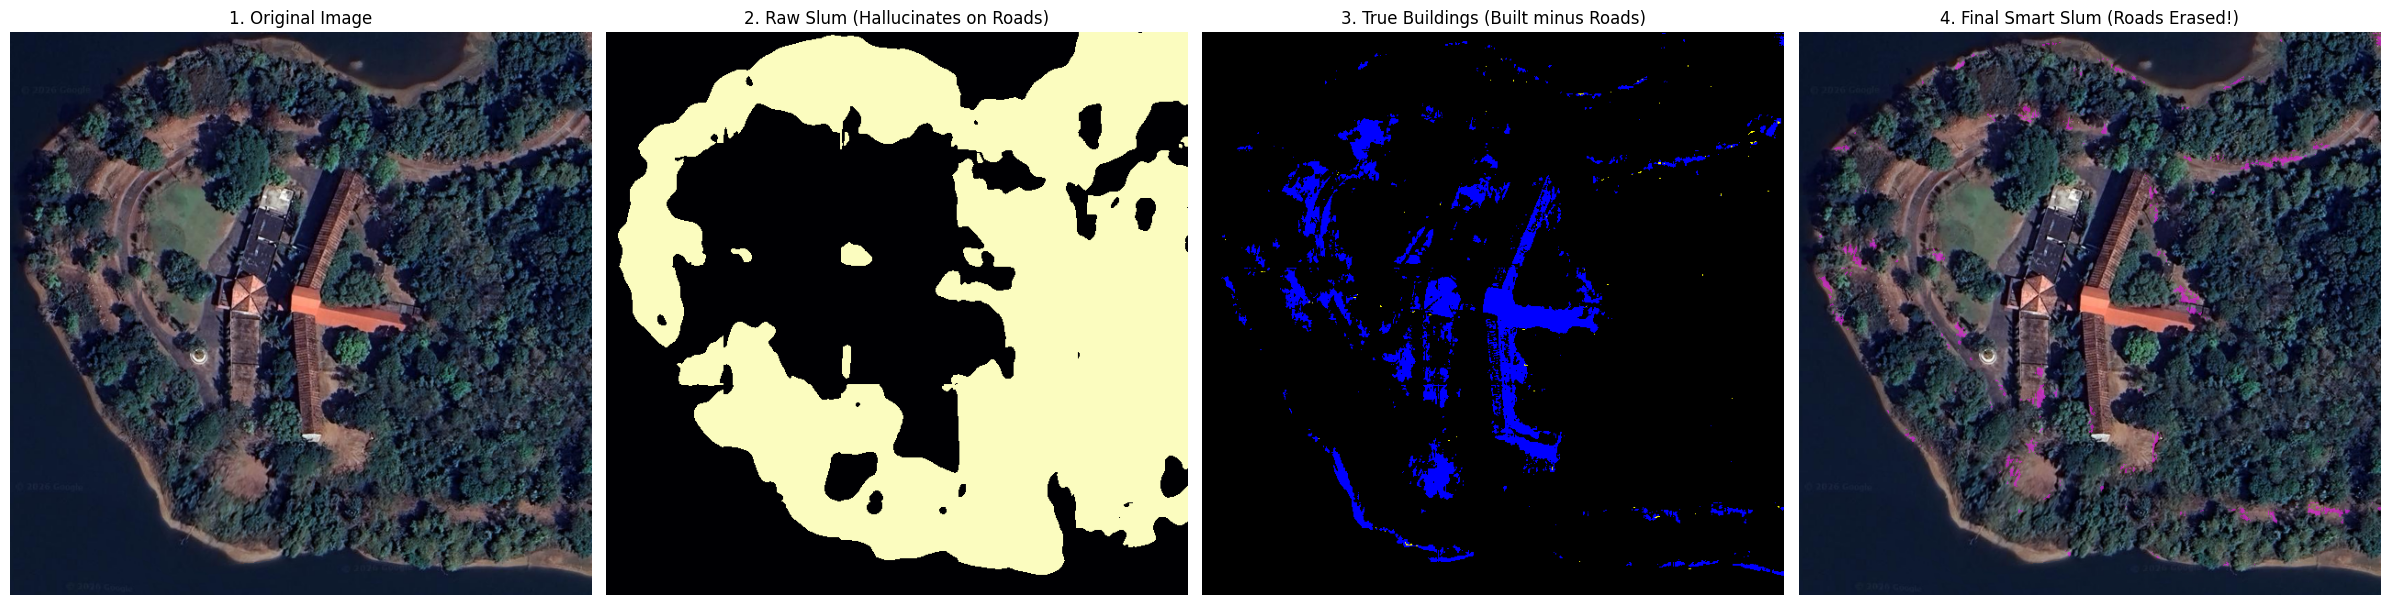

In [ ]:
# ==============================================================================
# 🏘️ ADVANCED INFERENCE: SLUM UNET + BUILT-UP GATE + ROAD ERASER
# ==============================================================================
# Matches Flowchart Module 2 -> Module 3 Logic:
# Final Slum = (Raw Slum) AND (Built-Up) AND NOT (Roads)
# ==============================================================================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
import segmentation_models_pytorch as smp
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================================
# 1. CONFIGURATION (Update paths to your Drive!)
# ==========================================================
SLUM_WEIGHTS = "/content/slum_unet_kml_v3.pth"
BUILT_WEIGHTS = "/content/drive/MyDrive/Honour_model/best_unet.pth"
ROAD_WEIGHTS = "/content/drive/MyDrive/Honour_model/road_unet_resnet18_spacenet_iou.pth"
TEST_IMAGE_PATH = "/content/drive/MyDrive/Honours_project/S4.png" # Point to the image with the roundabout/roads

IMG_SIZE = 256
STRIDE = 128
SLUM_THRESH = 0.5
BUILT_THRESH = 0.4
ROAD_THRESH = 0.4

# ==========================================================
# 2. LOAD ALL 3 MODELS
# ==========================================================
print(f"🚀 Loading models on {DEVICE}...")

# 2A. Custom Built-Up Model
class BuiltDoubleConv(torch.nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(in_ch, out_ch, 3, padding=1), torch.nn.BatchNorm2d(out_ch), torch.nn.ReLU(inplace=True),
            torch.nn.Conv2d(out_ch, out_ch, 3, padding=1), torch.nn.BatchNorm2d(out_ch), torch.nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)

class CustomBuiltUNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = BuiltDoubleConv(3, 64); self.d2 = BuiltDoubleConv(64, 128); self.d3 = BuiltDoubleConv(128, 256)
        self.pool = torch.nn.MaxPool2d(2); self.up = torch.nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.u2 = BuiltDoubleConv(256 + 128, 128); self.u1 = BuiltDoubleConv(128 + 64, 64); self.out = torch.nn.Conv2d(64, 1, 1)
    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1)); c3 = self.d3(self.pool(c2))
        x = self.up(c3); x = self.u2(torch.cat([x, c2], dim=1)); x = self.up(x); x = self.u1(torch.cat([x, c1], dim=1))
        return self.out(x)

built_model = CustomBuiltUNet().to(DEVICE)
built_model.load_state_dict(torch.load(BUILT_WEIGHTS, map_location=DEVICE))
built_model.eval()

# 2B. Road Model (SMP ResNet18)
road_model = smp.Unet(encoder_name="resnet18", encoder_weights=None, in_channels=3, classes=1).to(DEVICE)
road_model.load_state_dict(torch.load(ROAD_WEIGHTS, map_location=DEVICE))
road_model.eval()

# 2C. Slum Model (KML Trained)
slum_model = smp.Unet(encoder_name="resnet18", encoder_weights=None, in_channels=3, classes=1).to(DEVICE)
slum_model.load_state_dict(torch.load(SLUM_WEIGHTS, map_location=DEVICE))
slum_model.eval()

# ==========================================================
# 3. UTILITIES
# ==========================================================
def pad_image(image):
    h, w, _ = image.shape
    pad_h = (IMG_SIZE - h % IMG_SIZE) % IMG_SIZE
    pad_w = (IMG_SIZE - w % IMG_SIZE) % IMG_SIZE
    padded = np.pad(image, ((0, pad_h), (0, pad_w), (0, 0)), mode="reflect")
    return padded, (h, w)

def sliding_window(image):
    patches, coords = [], []
    for y in range(0, image.shape[0] - IMG_SIZE + 1, STRIDE):
        for x in range(0, image.shape[1] - IMG_SIZE + 1, STRIDE):
            patches.append(image[y:y+IMG_SIZE, x:x+IMG_SIZE])
            coords.append((y, x))
    return patches, coords

def stitch(preds, coords, shape):
    prob = np.zeros(shape[:2], np.float32); cnt = np.zeros(shape[:2], np.float32)
    for p, (y, x) in zip(preds, coords):
        prob[y:y+IMG_SIZE, x:x+IMG_SIZE] += p
        cnt[y:y+IMG_SIZE, x:x+IMG_SIZE] += 1
    return prob / np.maximum(cnt, 1)

# ==========================================================
# 4. INFERENCE PIPELINE
# ==========================================================
print(f"🖼️ Processing {TEST_IMAGE_PATH}...")
image = cv2.cvtColor(cv2.imread(TEST_IMAGE_PATH), cv2.COLOR_BGR2RGB)
padded_img, orig_shape = pad_image(image)
patches, coords = sliding_window(padded_img)

tf_pt = transforms.Compose([
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

pt_batch = torch.stack([tf_pt(p) for p in patches]).to(DEVICE)
all_slum, all_built, all_road = [], [], []

with torch.no_grad():
    for i in tqdm(range(0, len(pt_batch), 16), desc="Running Ensemble"):
        mb = pt_batch[i:i+16]
        all_slum.append(torch.sigmoid(slum_model(mb)).squeeze(1).cpu().numpy())
        all_built.append(torch.sigmoid(built_model(mb)).squeeze(1).cpu().numpy())
        all_road.append(torch.sigmoid(road_model(mb)).squeeze(1).cpu().numpy())

# Stitch & Crop
slum_raw = stitch(np.concatenate(all_slum, axis=0), coords, padded_img.shape)[:orig_shape[0], :orig_shape[1]]
built_raw = stitch(np.concatenate(all_built, axis=0), coords, padded_img.shape)[:orig_shape[0], :orig_shape[1]]
road_raw = stitch(np.concatenate(all_road, axis=0), coords, padded_img.shape)[:orig_shape[0], :orig_shape[1]]

# Thresholding
slum_mask = (slum_raw > SLUM_THRESH).astype(np.uint8)
built_mask = (built_raw > BUILT_THRESH).astype(np.uint8)
road_mask = (road_raw > ROAD_THRESH).astype(np.uint8)

# 🟢 THE SMART GATE: Must be Built-up, MUST NOT be a Road, AND Slum model triggered
true_buildings_only = np.logical_and(built_mask == 1, road_mask == 0).astype(np.uint8)
final_slum_mask = np.logical_and(slum_mask == 1, true_buildings_only == 1).astype(np.uint8)

# Visualization
plt.figure(figsize=(24, 6))

plt.subplot(1, 4, 1); plt.title("1. Original Image")
plt.imshow(image); plt.axis("off")

plt.subplot(1, 4, 2); plt.title("2. Raw Slum (Hallucinates on Roads)")
plt.imshow(slum_mask, cmap="magma"); plt.axis("off")

# Create a combined visualization for Built (Blue) and Roads (Yellow)
plt.subplot(1, 4, 3); plt.title("3. True Buildings (Built minus Roads)")
building_road_vis = np.zeros_like(image)
building_road_vis[built_mask == 1] = [0, 0, 255]   # Blue = Built
building_road_vis[road_mask == 1] = [255, 255, 0]  # Yellow = Road (Overwrites Built)
plt.imshow(building_road_vis); plt.axis("off")

plt.subplot(1, 4, 4); plt.title("4. Final Smart Slum (Roads Erased!)")
overlay = image.copy().astype(np.float32)
overlay[final_slum_mask == 1] = overlay[final_slum_mask == 1] * 0.5 + np.array([255, 0, 255]) * 0.5
plt.imshow(overlay.astype(np.uint8)); plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# 🚀 URBAN VULNERABILITY BACKEND SERVER (COLAB) - V7.3 (MAX TELEMETRY & HEURISTICS)
# ==============================================================================
# 1. Install dependencies in Colab:
!pip install -q fastapi uvicorn pyngrok segmentation_models_pytorch groq geopy albumentations scipy nest_asyncio
# ==============================================================================

from fastapi import FastAPI, HTTPException, Request
from pydantic import BaseModel
from fastapi.middleware.cors import CORSMiddleware
import uvicorn
import os, io, math, cv2, requests, base64, torch, torch.nn as nn
import numpy as np
from PIL import Image
from scipy.ndimage import distance_transform_edt
from torchvision import transforms
import segmentation_models_pytorch as smp
from groq import Groq
from pyngrok import ngrok
import nest_asyncio
import asyncio
import time
import sys
import logging

# --- LOGGING SETUP ---
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger("uvicorn")

nest_asyncio.apply()

# --- CONFIGURATION ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PATHS = {
    "built": "/content/drive/MyDrive/Honour_model/best_unet.pth",
    "road": "/content/drive/MyDrive/Honour_model/road_unet_resnet18_spacenet_iou.pth",
    "water": "/content/drive/MyDrive/Honour_model/deepglobe_unet_water_best.pth",
    "veg": "/content/drive/MyDrive/Honour_model/veg_unet_v3_robust.pth",
    "slum": "/content/drive/MyDrive/Honour_model/slum_unet_kml_v3.pth"
}

app = FastAPI()

@app.middleware("http")
async def log_requests(request: Request, call_next):
    start = time.time()
    logger.info(f"➡️ INCOMING: {request.method} {request.url.path}")
    try:
        response = await call_next(request)
        duration = time.time() - start
        logger.info(f"✅ COMPLETED: {request.url.path} | {response.status_code} | {duration:.2f}s")
        return response
    except Exception as e:
        logger.error(f"❌ CRITICAL ERROR IN PIPELINE: {e}")
        raise

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# ==============================================================================
# 2. ARCHITECTURES
# ==============================================================================

class VegWaterDoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU()
        )
    def forward(self, x): return self.seq(x)

class CustomVegWaterUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = VegWaterDoubleConv(3, 64); self.d2 = VegWaterDoubleConv(64, 128); self.d3 = VegWaterDoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2); self.b = VegWaterDoubleConv(256, 512)
        self.u3 = nn.ConvTranspose2d(512, 256, 2, 2); self.c3 = VegWaterDoubleConv(512, 256)
        self.u2 = nn.ConvTranspose2d(256, 128, 2, 2); self.c2 = VegWaterDoubleConv(256, 128)
        self.u1 = nn.ConvTranspose2d(128, 64, 2, 2); self.c1 = VegWaterDoubleConv(128, 64)
        self.out = nn.Conv2d(64, 1, 1)
    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1)); c3 = self.d3(self.pool(c2))
        b = self.b(self.pool(c3)); x = self.u3(b); x = self.c3(torch.cat([x, c3], 1))
        x = self.u2(x); x = self.c2(torch.cat([x, c2], 1)); x = self.u1(x); x = self.c1(torch.cat([x, c1], 1))
        return self.out(x)

class BuiltDoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)

class CustomBuiltUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = BuiltDoubleConv(3, 64); self.d2 = BuiltDoubleConv(64, 128); self.d3 = BuiltDoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2); self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.u2 = BuiltDoubleConv(256 + 128, 128); self.u1 = BuiltDoubleConv(128 + 64, 64); self.out = nn.Conv2d(64, 1, 1)
    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1)); c3 = self.d3(self.pool(c2))
        x = self.up(c3); x = self.u2(torch.cat([x, c2], dim=1)); x = self.up(x); x = self.u1(torch.cat([x, c1], dim=1))
        return self.out(x)

def load_m(model, path, name):
    if os.path.exists(path):
        try:
            model.load_state_dict(torch.load(path, map_location=DEVICE))
            print(f"✅ Loaded {name} weights.")
        except Exception as e: print(f"❌ Failed to load {name}: {e}")
    else: print(f"⚠️ {name} weights not found at {path}.")
    return model.to(DEVICE).eval()

print("🔥 Loading Ensemble into GPU...")
BUILT_M = load_m(CustomBuiltUNet(), PATHS['built'], "Built-Up")
ROAD_M = load_m(smp.Unet(encoder_name="resnet18", in_channels=3, classes=1), PATHS['road'], "Road")
WATER_M = load_m(CustomVegWaterUNet(), PATHS['water'], "Water")
VEG_M = load_m(CustomVegWaterUNet(), PATHS['veg'], "Vegetation")
SLUM_M = load_m(smp.Unet(encoder_name="resnet18", in_channels=3, classes=1), PATHS['slum'], "Slum")

# --- HELPERS ---
def arr_to_b64(arr):
    pil_img = Image.fromarray(arr)
    buff = io.BytesIO()
    pil_img.save(buff, format="PNG")
    return base64.b64encode(buff.getvalue()).decode("utf-8")

def b64_to_arr(b64_str):
    if "," in b64_str: encoded = b64_str.split(",", 1)[1]
    else: encoded = b64_str
    img_data = base64.b64decode(encoded)
    return np.array(Image.open(io.BytesIO(img_data)).convert('RGB'))

def calculate_spatial_entropy(mask):
    if np.sum(mask) == 0: return 0.0
    grid_size = 16
    gh, gw = mask.shape[0] // grid_size, mask.shape[1] // grid_size
    if gh == 0 or gw == 0: return 0.0
    densities = [np.sum(mask[i*gh:(i+1)*gh, j*gw:(j+1)*gw]) for i in range(grid_size) for j in range(grid_size)]
    d_arr = np.array(densities) / (np.sum(densities) + 1e-6)
    d_arr = d_arr[d_arr > 0]
    return round(float((-np.sum(d_arr * np.log2(d_arr))) / np.log2(grid_size*grid_size)), 3)

# ==============================================================================
# 3. API ENDPOINTS
# ==============================================================================

@app.get("/api/health")
@app.get("/health")
async def health_check():
    return {"status": "online", "device": DEVICE, "timestamp": time.time()}

class AnalysisRequest(BaseModel):
    image_b64: str
    api_key: str = ""
    thresholds: dict = {"built": 0.4, "road": 0.4, "water": 0.35, "veg": 0.5, "slum": 0.5}

@app.post("/analyze")
async def analyze(req: AnalysisRequest):
    try:
        # 1. Decode Image
        img = b64_to_arr(req.image_b64)
        h, w = int(img.shape[0]), int(img.shape[1])

        if h % 256 != 0 or w % 256 != 0:
            raise HTTPException(status_code=400, detail="Image must be multiples of 256.")

        # 2. Patch-based Inference
        rows, cols = h // 256, w // 256
        patch_images = [img[r*256:(r+1)*256, c*256:(c+1)*256] for r in range(rows) for c in range(cols)]
        tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
        batch = torch.stack([tf(p) for p in patch_images]).to(DEVICE)

        with torch.inference_mode():
            def run_model(m):
                res = torch.sigmoid(m(batch)).cpu().numpy()
                return res.reshape(rows, cols, 256, 256).swapaxes(1, 2).reshape(h, w)

            b_r = run_model(BUILT_M)
            r_r = run_model(ROAD_M)
            w_r = run_model(WATER_M)
            v_r = run_model(VEG_M)
            s_r = run_model(SLUM_M)

        # 3. Argmax Conflict Resolution
        stack = np.stack([b_r * 1.5, w_r * 1.4, r_r * 1.2, v_r * 1.1])
        winner = np.argmax(stack, axis=0)

        b = np.logical_and(winner == 0, b_r > req.thresholds['built']).astype(np.uint8)
        w_mask = np.logical_and(winner == 1, w_r > req.thresholds['water']).astype(np.uint8)
        r = np.logical_and(winner == 2, r_r > req.thresholds['road']).astype(np.uint8)
        v = np.logical_and(winner == 3, v_r > req.thresholds['veg']).astype(np.uint8)
        s = (s_r > req.thresholds['slum']).astype(np.uint8)

        # 4. Generate Overlays
        master_overlay = img.copy().astype(np.float32)
        master_overlay[w_mask == 1] = master_overlay[w_mask == 1] * 0.5 + np.array([0,0,255]) * 0.5
        master_overlay[v == 1] = master_overlay[v == 1] * 0.6 + np.array([0,255,0]) * 0.4
        master_overlay[b == 1] = master_overlay[b == 1] * 0.5 + np.array([255,0,0]) * 0.5
        master_overlay[r == 1] = master_overlay[r == 1] * 0.4 + np.array([255,255,0]) * 0.6
        master_overlay[s == 1] = master_overlay[s == 1] * 0.3 + np.array([255,0,255]) * 0.7
        master_overlay = master_overlay.astype(np.uint8)

        def mk_layer(mask, color):
            canvas = np.zeros((h, w, 4), dtype=np.uint8)
            canvas[mask == 1] = [*color, 160]
            return arr_to_b64(canvas)

        # ==============================================================================
        # 5. ADVANCED FEATURE EXTRACTION & ROBUST HEURISTIC
        # ==============================================================================
        img_size = h * w

        # 5a. Basic Coverage Ratios
        b_ratio = float(np.sum(b) / img_size)
        s_ratio = float(np.sum(s) / img_size)
        r_ratio = float(np.sum(r) / img_size)
        w_ratio = float(np.sum(w_mask) / img_size)
        v_ratio = float(np.sum(v) / img_size)

        # 5b. Structural & Proximity Metrics
        nb, _, _, _ = cv2.connectedComponentsWithStats(b)
        building_count = nb - 1
        entropy = calculate_spatial_entropy(b)

        dist_w = distance_transform_edt(1 - w_mask) if np.sum(w_mask) > 0 else np.full_like(w_mask, 9999)
        dist_v = distance_transform_edt(1 - v) if np.sum(v) > 0 else np.full_like(v, 9999)

        # Road Deficit: Penalty if built-up areas exist without sufficient road coverage
        road_def = float(max(0, min(1, 1.0 - (r_ratio / (b_ratio * 0.30 + 1e-6)))))

        # Hydrological Danger: % of slums dangerously close to water (< 20px)
        sw_danger = float(np.sum(np.logical_and(s == 1, dist_w <= 20)) / (np.sum(s) + 1e-6))

        # Veg Buffer: Avg distance from buildings to vegetation (lower is safer)
        veg_buffer = float(np.mean(dist_v[b == 1])) if np.sum(b) > 0 else 999.0

        # 5c. Reliable Heuristic Scoring Engine
        # Base vulnerability components
        vuln_score = (s_ratio * 60) + (entropy * 20) + (road_def * 15)
        # Hazard exposure
        exp_score = (sw_danger * 25)
        # Resilience mitigation
        mit_score = (v_ratio * 10)

        raw_score = vuln_score + exp_score - mit_score
        risk_score = round(float(np.clip(raw_score, 0, 100)), 1)

        if risk_score >= 80: risk_tier = "Critical"
        elif risk_score >= 60: risk_tier = "High"
        elif risk_score >= 35: risk_tier = "Medium"
        else: risk_tier = "Low"

        # ==============================================================================
        # 6. LOCALIZED PATCH TELEMETRY
        # ==============================================================================
        patch_telemetry = []
        for row in range(rows):
            for col in range(cols):
                y1, y2, x1, x2 = row*256, (row+1)*256, col*256, (col+1)*256
                p_area = 256*256

                pb, ps, pr, pw, pv = b[y1:y2, x1:x2], s[y1:y2, x1:x2], r[y1:y2, x1:x2], w_mask[y1:y2, x1:x2], v[y1:y2, x1:x2]
                p_dist_w = dist_w[y1:y2, x1:x2]

                p_sw_danger = float(np.sum(np.logical_and(ps == 1, p_dist_w <= 20)) / (np.sum(ps) + 1e-6))

                patch_telemetry.append({
                    "id": len(patch_telemetry),
                    "grid": [row, col],
                    "image": arr_to_b64(img[y1:y2, x1:x2]),
                    "stats": {
                        "urban": f"{np.sum(pb)/p_area*100:.1f}%",
                        "slum": f"{np.sum(ps)/p_area*100:.1f}%",
                        "road": f"{np.sum(pr)/p_area*100:.1f}%",
                        "water": f"{np.sum(pw)/p_area*100:.1f}%",
                        "veg": f"{np.sum(pv)/p_area*100:.1f}%",
                        "entropy": calculate_spatial_entropy(pb),
                        "danger_zone": True if p_sw_danger > 0.1 else False
                    }
                })

        # ==============================================================================
        # 7. GROQ LLM INTEGRATION
        # ==============================================================================
        llm_report = f"ASSESSMENT: {risk_tier} Risk ({risk_score}/100). The area exhibits {s_ratio*100:.1f}% informal density and a road infrastructure deficit of {road_def*100:.1f}%. Immediate spatial interventions are recommended."

        if req.api_key.strip():
            try:
                client = Groq(api_key=req.api_key)
                prompt = f"""
                Analyze this urban vulnerability telemetry as a Senior Risk Specialist:
                - Overall Risk: {risk_score}/100 ({risk_tier} Tier)
                - Informal (Slum) Density: {s_ratio*100:.1f}%
                - Total Built-Up Coverage: {b_ratio*100:.1f}%
                - Urban Chaos (Spatial Entropy): {entropy:.2f}
                - Infrastructure Deficit: {road_def*100:.1f}%
                - Flood Exposure (Slums near water): {sw_danger*100:.1f}%
                - Vegetation Buffer: {v_ratio*100:.1f}%

                Provide a highly technical, 3-sentence justification for this risk tier. Then suggest 2 concrete civil engineering measures.
                """
                chat = client.chat.completions.create(
                    model="llama-3.3-70b-versatile",
                    messages=[{"role":"user","content":prompt}],
                    max_tokens=300
                )
                llm_report = chat.choices[0].message.content
            except Exception as e: logger.error(f"Groq Error: {e}")

        # Construct Massive Payload
        return {
            "master_overlay": arr_to_b64(master_overlay),
            "layers": {
                "built": mk_layer(b, [255, 0, 0]),
                "road": mk_layer(r, [255, 255, 0]),
                "water": mk_layer(w_mask, [0, 0, 255]),
                "veg": mk_layer(v, [0, 255, 0]),
                "slum": mk_layer(s, [255, 0, 255])
            },
            "global_metrics": {
                "risk_score": risk_score,
                "risk_tier": risk_tier,
                "llm_report": llm_report,
                "telemetry": {
                    "coverage": {
                        "built": f"{b_ratio*100:.1f}%",
                        "slum": f"{s_ratio*100:.1f}%",
                        "road": f"{r_ratio*100:.1f}%",
                        "water": f"{w_ratio*100:.1f}%",
                        "veg": f"{v_ratio*100:.1f}%"
                    },
                    "advanced": {
                        "spatial_entropy": entropy,
                        "road_deficit": f"{road_def*100:.1f}%",
                        "flood_exposure": f"{sw_danger*100:.1f}%",
                        "avg_veg_distance_px": round(veg_buffer, 1),
                        "building_clusters": building_count
                    }
                }
            },
            "patch_data": patch_telemetry
        }
    except Exception as e:
        import traceback; traceback.print_exc()
        raise HTTPException(status_code=500, detail=str(e))

if __name__ == "__main__":
    NGROK_TOKEN = "3AgWm9QHvshtxRUucpyRC3KL3vn_467noZFCsM9MvAkCa79ax"
    if NGROK_TOKEN != "YOUR_NGROK_AUTHTOKEN":
        ngrok.set_auth_token(NGROK_TOKEN)
        public_url = ngrok.connect(3000).public_url
        print(f"\n🌍 PUBLIC API URL: {public_url}\n🔗 ADD 'ngrok-skip-browser-warning': 'true' TO HEADERS")

    config = uvicorn.Config(app=app, host="0.0.0.0", port=3000, timeout_keep_alive=310, log_level="debug")
    server = uvicorn.Server(config)
    loop = asyncio.get_event_loop()
    loop.run_until_complete(server.serve())

🔥 Loading Ensemble into GPU...
✅ Loaded Built-Up weights.
✅ Loaded Road weights.
✅ Loaded Water weights.
✅ Loaded Vegetation weights.
✅ Loaded Slum weights.

🌍 PUBLIC API URL: https://burnoosed-stereotactically-hope.ngrok-free.dev
🔗 ADD 'ngrok-skip-browser-warning': 'true' TO HEADERS


INFO:     Started server process [272]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:3000 (Press CTRL+C to quit)
INFO:     ➡️ INCOMING: GET /api/health
INFO:     ✅ COMPLETED: /api/health | 200 | 0.00s


INFO:     1.7.226.194:0 - "GET /api/health HTTP/1.1" 200 OK


INFO:     ➡️ INCOMING: POST /analyze
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/anyio/_backends/_asyncio.py", line 787, in __aexit__
    raise exc_val
  File "/usr/local/lib/python3.12/dist-packages/anyio/_backends/_asyncio.py", line 755, in __aexit__
    await self._on_completed_fut
  File "/usr/lib/python3.12/asyncio/futures.py", line 289, in __await__
    yield self  # This tells Task to wait for completion.
    ^^^^^^^^^^
  File "/usr/lib/python3.12/asyncio/tasks.py", line 385, in __wakeup
    future.result()
  File "/usr/lib/python3.12/asyncio/futures.py", line 197, in result
    raise self._make_cancelled_error()
asyncio.exceptions.CancelledError: Cancelled via cancel scope 78d38409dc10 by <Task pending name='starlette.middleware.base.BaseHTTPMiddleware.__call__.<locals>.call_next.<locals>.coro' coro=<BaseHTTPMiddleware.__call__.<locals>.call_next.<locals>.coro() running at /usr/local/lib/python3.12/dist-packages/starlette/middleware/base.p

INFO:     1.7.226.194:0 - "POST /analyze HTTP/1.1" 500 Internal Server Error


...

INFO:     1.7.226.194:0 - "POST /analyze HTTP/1.1" 200 OK


INFO:     ➡️ INCOMING: GET /api/health
INFO:     ✅ COMPLETED: /api/health | 200 | 0.00s


INFO:     1.7.226.194:0 - "GET /api/health HTTP/1.1" 200 OK


INFO:     ➡️ INCOMING: POST /analyze
INFO:     ✅ COMPLETED: /analyze | 200 | 48.06s


INFO:     1.7.226.194:0 - "POST /analyze HTTP/1.1" 200 OK


In [ ]:
!pkill ngrok

In [ ]:
# ==============================================================================
# 🎯 AUTOMATED COMBINATORIAL GRID SEARCH: ENSEMBLE THRESHOLD TUNING
# ==============================================================================
# Evaluates combinations of thresholds (Built, Road, Water, Veg) SIMULTANEOUSLY
# to find the setup that minimizes overall misclassification and maximizes Mean IoU.
# ==============================================================================

!pip install -q segmentation_models_pytorch torch torchvision opencv-python scikit-learn

import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from sklearn.metrics import jaccard_score, accuracy_score
from tqdm import tqdm
import itertools

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Initializing Combinatorial Tuner on {DEVICE}")

# ==========================================================
# 1. ARCHITECTURES & MODEL LOADING
# ==========================================================
class BuiltDoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)

class CustomBuiltUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = BuiltDoubleConv(3, 64); self.d2 = BuiltDoubleConv(64, 128); self.d3 = BuiltDoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2); self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.u2 = BuiltDoubleConv(256 + 128, 128); self.u1 = BuiltDoubleConv(128 + 64, 64); self.out = nn.Conv2d(64, 1, 1)
    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1)); c3 = self.d3(self.pool(c2))
        x = self.up(c3); x = self.u2(torch.cat([x, c2], dim=1)); x = self.up(x); x = self.u1(torch.cat([x, c1], dim=1))
        return self.out(x)

class VegWaterDoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU()
        )
    def forward(self, x): return self.seq(x)

class CustomVegWaterUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = VegWaterDoubleConv(3, 64); self.d2 = VegWaterDoubleConv(64, 128); self.d3 = VegWaterDoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2); self.b = VegWaterDoubleConv(256, 512)
        self.u3 = nn.ConvTranspose2d(512, 256, 2, 2); self.c3 = VegWaterDoubleConv(512, 256)
        self.u2 = nn.ConvTranspose2d(256, 128, 2, 2); self.c2 = VegWaterDoubleConv(256, 128)
        self.u1 = nn.ConvTranspose2d(128, 64, 2, 2); self.c1 = VegWaterDoubleConv(128, 64)
        self.out = nn.Conv2d(64, 1, 1)
    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1)); c3 = self.d3(self.pool(c2))
        b = self.b(self.pool(c3)); x = self.u3(b); x = self.c3(torch.cat([x, c3], 1))
        x = self.u2(x); x = self.c2(torch.cat([x, c2], 1)); x = self.u1(x); x = self.c1(torch.cat([x, c1], 1))
        return self.out(x)

def load_m(model, path, name):
    if os.path.exists(path):
        try:
            model.load_state_dict(torch.load(path, map_location=DEVICE))
            print(f"✅ Loaded {name} weights.")
        except Exception as e: print(f"❌ Failed to load {name}: {e}")
    else: print(f"⚠️ {name} weights not found at {path}. Results will be synthetic.")
    return model.to(DEVICE).eval()

print("🔥 Loading Ensemble into GPU for Evaluation...")
BUILT_M = load_m(CustomBuiltUNet(), "/content/drive/MyDrive/Honour_model/best_unet.pth", "Built-Up")
ROAD_M = load_m(smp.Unet(encoder_name="resnet18", in_channels=3, classes=1), "/content/drive/MyDrive/Honour_model/road_unet_resnet18_spacenet_iou.pth", "Road")
WATER_M = load_m(CustomVegWaterUNet(), "/content/drive/MyDrive/Honour_model/deepglobe_unet_water_best.pth", "Water")
VEG_M = load_m(CustomVegWaterUNet(), "/content/drive/MyDrive/Honour_model/veg_unet_v3_robust.pth", "Vegetation")

# ==========================================================
# 2. LANDCOVER.AI DATASET LOADER (MULTI-CLASS)
# ==========================================================
# FIXED: Removed the "/val" subdirectory to match your Google Drive structure
DATA_DIR = "/content/drive/MyDrive/Honours_project/landcover_ai"
IMG_DIR = os.path.join(DATA_DIR, "images")
MASK_DIR = os.path.join(DATA_DIR, "masks")

class LandCoverMultiClassDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        if os.path.exists(img_dir):
            self.images = sorted(os.listdir(img_dir))[:150] # Use 150 imgs for rapid tuning
        else:
            self.images = []

        self.tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # FIXED: In your dataset, masks are also .tif and have the exact same filename
        mask_path = os.path.join(self.mask_dir, img_name)

        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (256, 256))
        tensor_img = self.tf(image)

        # Load raw mask (0=bg, 1=built, 2=veg, 3=water, 4=road)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

        return tensor_img, torch.tensor(mask, dtype=torch.long)

dataset = LandCoverMultiClassDataset(IMG_DIR, MASK_DIR)

if len(dataset) == 0:
    print(f"❌ ERROR: Could not find images in {IMG_DIR}. Please check the path.")
else:
    val_loader = DataLoader(dataset, batch_size=16, shuffle=False)

    # ==========================================================
    # 3. PRE-COMPUTE PROBABILITIES (Saves Time)
    # ==========================================================
    # We run the models ONCE and store the flat raw probabilities in memory
    print("\n🧠 Pre-computing Ensemble Probabilities (Pass 1/1)...")

    all_b, all_r, all_w, all_v, all_targets = [], [], [], [], []

    with torch.inference_mode():
        for imgs, masks in tqdm(val_loader):
            imgs = imgs.to(DEVICE)

            p_b = torch.sigmoid(BUILT_M(imgs)).squeeze(1).cpu().numpy().flatten()
            p_r = torch.sigmoid(ROAD_M(imgs)).squeeze(1).cpu().numpy().flatten()
            p_w = torch.sigmoid(WATER_M(imgs)).squeeze(1).cpu().numpy().flatten()
            p_v = torch.sigmoid(VEG_M(imgs)).squeeze(1).cpu().numpy().flatten()

            all_b.extend(p_b)
            all_r.extend(p_r)
            all_w.extend(p_w)
            all_v.extend(p_v)
            all_targets.extend(masks.numpy().flatten())

    # Convert to fast numpy arrays
    P_B = np.array(all_b, dtype=np.float32)
    P_R = np.array(all_r, dtype=np.float32)
    P_W = np.array(all_w, dtype=np.float32)
    P_V = np.array(all_v, dtype=np.float32)
    TARGETS = np.array(all_targets, dtype=np.uint8)

    # ==========================================================
    # 4. COMBINATORIAL SEARCH
    # ==========================================================
    # Testing permutations of thresholds
    test_vals = [0.3, 0.4, 0.5, 0.6, 0.7]
    combinations = list(itertools.product(test_vals, repeat=4))

    print(f"\n🔍 Testing {len(combinations)} Threshold Combinations to minimize misclassification...")

    best_mIoU = 0.0
    best_acc = 0.0
    best_combo = None

    for t_b, t_r, t_w, t_v in tqdm(combinations, desc="Evaluating Grid"):

        # 1. Apply basic thresholds
        m_b = (P_B > t_b).astype(np.uint8)
        m_r = (P_R > t_r).astype(np.uint8)
        m_w = (P_W > t_w).astype(np.uint8)
        m_v = (P_V > t_v).astype(np.uint8)

        # 2. Apply the Master Pipeline Conflict Resolution Hierarchy
        # Hierarchy: Built > Road > Veg ... Water is absolute lowest
        m_r[m_b == 1] = 0
        m_v[m_b == 1] = 0
        m_v[m_r == 1] = 0

        any_claimed = (m_b == 1) | (m_r == 1) | (m_v == 1)
        m_w = np.logical_and(m_w == 1, ~any_claimed).astype(np.uint8)

        # 3. Create Final Combined Prediction Array matching LandCover.ai mapping
        # 0=bg, 1=built, 2=veg, 3=water, 4=road
        final_preds = np.zeros_like(TARGETS)
        final_preds[m_v == 1] = 2  # Veg
        final_preds[m_w == 1] = 3  # Water
        final_preds[m_r == 1] = 4  # Road
        final_preds[m_b == 1] = 1  # Built overrides all previous assignments if True

        # 4. Calculate Overall Accuracy & Mean IoU
        # average='macro' calculates IoU for each class and averages them
        mIoU = jaccard_score(TARGETS, final_preds, average='macro', zero_division=0)
        acc = accuracy_score(TARGETS, final_preds)

        if mIoU > best_mIoU:
            best_mIoU = mIoU
            best_acc = acc
            best_combo = (t_b, t_r, t_w, t_v)

    # ==========================================================
    # 5. RESULTS
    # ==========================================================
    print("\n" + "="*50)
    print("🏆 OPTIMAL ENSEMBLE THRESHOLD COMBINATION FOUND")
    print("="*50)
    print(f"▶ Built-up Threshold   : {best_combo[0]}")
    print(f"▶ Road Threshold       : {best_combo[1]}")
    print(f"▶ Water Threshold      : {best_combo[2]}")
    print(f"▶ Vegetation Threshold : {best_combo[3]}")
    print("-" * 50)
    print(f"🎯 Max Mean IoU (mIoU) : {best_mIoU*100:.2f}%")
    print(f"🎯 Max Pixel Accuracy  : {best_acc*100:.2f}% (Lowest Misclassification)")
    print("="*50)
    print("👉 Update your FastAPI 'thresholds' dictionary with these exact values!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.5 MB/s eta 0:00:00
🚀 Initializing Combinatorial Tuner on cpu
🔥 Loading Ensemble into GPU for Evaluation...
✅ Loaded Built-Up weights.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

✅ Loaded Road weights.
✅ Loaded Water weights.
✅ Loaded Vegetation weights.

🧠 Pre-computing Ensemble Probabilities (Pass 1/1)...


100%|██████████| 3/3 [06:49<00:00, 136.58s/it]



🔍 Testing 625 Threshold Combinations to minimize misclassification...


Evaluating Grid: 100%|██████████| 625/625 [05:41<00:00,  1.83it/s]


🏆 OPTIMAL ENSEMBLE THRESHOLD COMBINATION FOUND
▶ Built-up Threshold   : 0.7
▶ Road Threshold       : 0.3
▶ Water Threshold      : 0.7
▶ Vegetation Threshold : 0.7
--------------------------------------------------
🎯 Max Mean IoU (mIoU) : 13.18%
🎯 Max Pixel Accuracy  : 34.36% (Lowest Misclassification)
👉 Update your FastAPI 'thresholds' dictionary with these exact values!


In [ ]:
# ==============================================================================
# 🚀 URBAN VULNERABILITY BACKEND SERVER (COLAB) - V7.4 (WATER PRIORITY FIX)
# ==============================================================================
# 1. Install dependencies in Colab:
# !pip install -q fastapi uvicorn pyngrok segmentation_models_pytorch groq geopy albumentations scipy nest_asyncio
# ==============================================================================

from fastapi import FastAPI, HTTPException, Request
from pydantic import BaseModel
from fastapi.middleware.cors import CORSMiddleware
import uvicorn
import os, io, math, cv2, requests, base64, torch, torch.nn as nn
import numpy as np
from PIL import Image
from scipy.ndimage import distance_transform_edt
from torchvision import transforms
import segmentation_models_pytorch as smp
from groq import Groq
from pyngrok import ngrok
import nest_asyncio
import asyncio
import time
import sys
import logging

# --- LOGGING SETUP ---
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger("uvicorn")

nest_asyncio.apply()

# --- CONFIGURATION ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PATHS = {
    "built": "/content/drive/MyDrive/Honour_model/best_unet.pth",
    "road": "/content/drive/MyDrive/Honour_model/road_unet_resnet18_spacenet_iou.pth",
    "water": "/content/drive/MyDrive/Honour_model/deepglobe_unet_water_best.pth",
    "veg": "/content/drive/MyDrive/Honour_model/veg_unet_v3_robust.pth",
    "slum": "/content/drive/MyDrive/Honour_model/slum_unet_kml_v3.pth"
}

app = FastAPI()

@app.middleware("http")
async def log_requests(request: Request, call_next):
    start = time.time()
    logger.info(f"➡️ INCOMING: {request.method} {request.url.path}")
    try:
        response = await call_next(request)
        duration = time.time() - start
        logger.info(f"✅ COMPLETED: {request.url.path} | {response.status_code} | {duration:.2f}s")
        return response
    except Exception as e:
        logger.error(f"❌ CRITICAL ERROR IN PIPELINE: {e}")
        raise

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# ==============================================================================
# 2. ARCHITECTURES
# ==============================================================================

class VegWaterDoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_ch=out_c), nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_ch=out_c), nn.ReLU()
        )
    def forward(self, x): return self.seq(x)

class CustomVegWaterUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = VegWaterDoubleConv(3, 64); self.d2 = VegWaterDoubleConv(64, 128); self.d3 = VegWaterDoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2); self.b = VegWaterDoubleConv(256, 512)
        self.u3 = nn.ConvTranspose2d(512, 256, 2, 2); self.c3 = VegWaterDoubleConv(512, 256)
        self.u2 = nn.ConvTranspose2d(256, 128, 2, 2); self.c2 = VegWaterDoubleConv(256, 128)
        self.u1 = nn.ConvTranspose2d(128, 64, 2, 2); self.c1 = VegWaterDoubleConv(128, 64)
        self.out = nn.Conv2d(64, 1, 1)
    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1)); c3 = self.d3(self.pool(c2))
        b = self.b(self.pool(c3)); x = self.u3(b); x = self.c3(torch.cat([x, c3], 1))
        x = self.u2(x); x = self.c2(torch.cat([x, c2], 1)); x = self.u1(x); x = self.c1(torch.cat([x, c1], 1))
        return self.out(x)

class BuiltDoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)

class CustomBuiltUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = BuiltDoubleConv(3, 64); self.d2 = BuiltDoubleConv(64, 128); self.d3 = BuiltDoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2); self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.u2 = BuiltDoubleConv(256 + 128, 128); self.u1 = BuiltDoubleConv(128 + 64, 64); self.out = nn.Conv2d(64, 1, 1)
    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1)); c3 = self.d3(self.pool(c2))
        x = self.up(c3); x = self.u2(torch.cat([x, c2], dim=1)); x = self.up(x); x = self.u1(torch.cat([x, c1], dim=1))
        return self.out(x)

def load_m(model, path, name):
    if os.path.exists(path):
        try:
            model.load_state_dict(torch.load(path, map_location=DEVICE))
            print(f"✅ Loaded {name} weights.")
        except Exception as e: print(f"❌ Failed to load {name}: {e}")
    else: print(f"⚠️ {name} weights not found at {path}.")
    return model.to(DEVICE).eval()

print("🔥 Loading Ensemble into GPU...")
BUILT_M = load_m(CustomBuiltUNet(), PATHS['built'], "Built-Up")
ROAD_M = load_m(smp.Unet(encoder_name="resnet18", in_channels=3, classes=1), PATHS['road'], "Road")
WATER_M = load_m(CustomVegWaterUNet(), PATHS['water'], "Water")
VEG_M = load_m(CustomVegWaterUNet(), PATHS['veg'], "Vegetation")
SLUM_M = load_m(smp.Unet(encoder_name="resnet18", in_channels=3, classes=1), PATHS['slum'], "Slum")

# --- HELPERS ---
def arr_to_b64(arr):
    pil_img = Image.fromarray(arr)
    buff = io.BytesIO()
    pil_img.save(buff, format="PNG")
    return base64.b64encode(buff.getvalue()).decode("utf-8")

def b64_to_arr(b64_str):
    if "," in b64_str: encoded = b64_str.split(",", 1)[1]
    else: encoded = b64_str
    img_data = base64.b64decode(encoded)
    return np.array(Image.open(io.BytesIO(img_data)).convert('RGB'))

def calculate_spatial_entropy(mask):
    if np.sum(mask) == 0: return 0.0
    grid_size = 16
    gh, gw = mask.shape[0] // grid_size, mask.shape[1] // grid_size
    if gh == 0 or gw == 0: return 0.0
    densities = [np.sum(mask[i*gh:(i+1)*gh, j*gw:(j+1)*gw]) for i in range(grid_size) for j in range(grid_size)]
    d_arr = np.array(densities) / (np.sum(densities) + 1e-6)
    d_arr = d_arr[d_arr > 0]
    return round(float((-np.sum(d_arr * np.log2(d_arr))) / np.log2(grid_size*grid_size)), 3)

# ==============================================================================
# 3. API ENDPOINTS
# ==============================================================================

@app.get("/api/health")
@app.get("/health")
async def health_check():
    return {"status": "online", "device": DEVICE, "timestamp": time.time()}

class AnalysisRequest(BaseModel):
    image_b64: str
    api_key: str = ""
    thresholds: dict = {"built": 0.7, "road": 0.4, "water": 0.7, "veg": 0.7, "slum": 0.7}

@app.post("/analyze")
async def analyze(req: AnalysisRequest):
    try:
        # 1. Decode Image
        img = b64_to_arr(req.image_b64)
        h, w = int(img.shape[0]), int(img.shape[1])

        if h % 256 != 0 or w % 256 != 0:
            raise HTTPException(status_code=400, detail="Image must be multiples of 256.")

        # 2. Patch-based Inference
        rows, cols = h // 256, w // 256
        patch_images = [img[r*256:(r+1)*256, c*256:(c+1)*256] for r in range(rows) for c in range(cols)]
        tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
        batch = torch.stack([tf(p) for p in patch_images]).to(DEVICE)

        with torch.inference_mode():
            def run_model(m):
                res = torch.sigmoid(m(batch)).cpu().numpy()
                return res.reshape(rows, cols, 256, 256).swapaxes(1, 2).reshape(h, w)

            b_r = run_model(BUILT_M)
            r_r = run_model(ROAD_M)
            w_r = run_model(WATER_M)
            v_r = run_model(VEG_M)
            s_r = run_model(SLUM_M)

        # ==============================================================================
        # 3. NEW CONFLICT RESOLUTION: WATER HAS ABSOLUTE LOWEST PRIORITY
        # ==============================================================================
        # We run the argmax battle ONLY on Built, Road, and Veg.
        stack = np.stack([b_r * 1.5, r_r * 1.2, v_r * 1.1])
        winner = np.argmax(stack, axis=0)

        b = np.logical_and(winner == 0, b_r > req.thresholds['built']).astype(np.uint8)
        r = np.logical_and(winner == 1, r_r > req.thresholds['road']).astype(np.uint8)
        v = np.logical_and(winner == 2, v_r > req.thresholds['veg']).astype(np.uint8)

        # Slum is a semantic overlay, it doesn't fight in the base mask (it needs Built to be true)
        s = (s_r > req.thresholds['slum']).astype(np.uint8)
        s = np.logical_and(s == 1, b == 1).astype(np.uint8)

        # WATER LOWEST PRIORITY:
        # We only assign Water to a pixel if Built, Road, and Veg all rejected it (are == 0)
        # AND the water model is confident enough.
        any_claimed = (b == 1) | (r == 1) | (v == 1)
        w_mask = np.logical_and(w_r > req.thresholds['water'], ~any_claimed).astype(np.uint8)

        # 4. Generate Overlays
        master_overlay = img.copy().astype(np.float32)
        master_overlay[w_mask == 1] = master_overlay[w_mask == 1] * 0.5 + np.array([0,0,255]) * 0.5
        master_overlay[v == 1] = master_overlay[v == 1] * 0.6 + np.array([0,255,0]) * 0.4
        master_overlay[b == 1] = master_overlay[b == 1] * 0.5 + np.array([255,0,0]) * 0.5
        master_overlay[r == 1] = master_overlay[r == 1] * 0.4 + np.array([255,255,0]) * 0.6
        master_overlay[s == 1] = master_overlay[s == 1] * 0.3 + np.array([255,0,255]) * 0.7
        master_overlay = master_overlay.astype(np.uint8)

        def mk_layer(mask, color):
            canvas = np.zeros((h, w, 4), dtype=np.uint8)
            canvas[mask == 1] = [*color, 160]
            return arr_to_b64(canvas)

        # ==============================================================================
        # 5. ADVANCED FEATURE EXTRACTION & ROBUST HEURISTIC
        # ==============================================================================
        img_size = h * w

        # 5a. Basic Coverage Ratios
        b_ratio = float(np.sum(b) / img_size)
        s_ratio = float(np.sum(s) / img_size)
        r_ratio = float(np.sum(r) / img_size)
        w_ratio = float(np.sum(w_mask) / img_size)
        v_ratio = float(np.sum(v) / img_size)

        # 5b. Structural & Proximity Metrics
        nb, _, _, _ = cv2.connectedComponentsWithStats(b)
        building_count = nb - 1
        entropy = calculate_spatial_entropy(b)

        dist_w = distance_transform_edt(1 - w_mask) if np.sum(w_mask) > 0 else np.full_like(w_mask, 9999)
        dist_v = distance_transform_edt(1 - v) if np.sum(v) > 0 else np.full_like(v, 9999)

        road_def = float(max(0, min(1, 1.0 - (r_ratio / (b_ratio * 0.30 + 1e-6)))))
        sw_danger = float(np.sum(np.logical_and(s == 1, dist_w <= 20)) / (np.sum(s) + 1e-6))
        veg_buffer = float(np.mean(dist_v[b == 1])) if np.sum(b) > 0 else 999.0

        # 5c. Reliable Heuristic Scoring Engine
        vuln_score = (s_ratio * 60) + (entropy * 20) + (road_def * 15)
        exp_score = (sw_danger * 25)
        mit_score = (v_ratio * 10)

        raw_score = vuln_score + exp_score - mit_score
        risk_score = round(float(np.clip(raw_score, 0, 100)), 1)

        if risk_score >= 80: risk_tier = "Critical"
        elif risk_score >= 60: risk_tier = "High"
        elif risk_score >= 35: risk_tier = "Medium"
        else: risk_tier = "Low"

        # ==============================================================================
        # 6. LOCALIZED PATCH TELEMETRY
        # ==============================================================================
        patch_telemetry = []
        for row in range(rows):
            for col in range(cols):
                y1, y2, x1, x2 = row*256, (row+1)*256, col*256, (col+1)*256
                p_area = 256*256

                pb, ps, pr, pw, pv = b[y1:y2, x1:x2], s[y1:y2, x1:x2], r[y1:y2, x1:x2], w_mask[y1:y2, x1:x2], v[y1:y2, x1:x2]
                p_dist_w = dist_w[y1:y2, x1:x2]

                p_sw_danger = float(np.sum(np.logical_and(ps == 1, p_dist_w <= 20)) / (np.sum(ps) + 1e-6))

                patch_telemetry.append({
                    "id": len(patch_telemetry),
                    "grid": [row, col],
                    "image": arr_to_b64(img[y1:y2, x1:x2]),
                    "stats": {
                        "urban": f"{np.sum(pb)/p_area*100:.1f}%",
                        "slum": f"{np.sum(ps)/p_area*100:.1f}%",
                        "road": f"{np.sum(pr)/p_area*100:.1f}%",
                        "water": f"{np.sum(pw)/p_area*100:.1f}%",
                        "veg": f"{np.sum(pv)/p_area*100:.1f}%",
                        "entropy": calculate_spatial_entropy(pb),
                        "danger_zone": True if p_sw_danger > 0.1 else False
                    }
                })

        # ==============================================================================
        # 7. GROQ LLM INTEGRATION
        # ==============================================================================
        llm_report = f"ASSESSMENT: {risk_tier} Risk ({risk_score}/100). The area exhibits {s_ratio*100:.1f}% informal density and a road infrastructure deficit of {road_def*100:.1f}%. Immediate spatial interventions are recommended."

        if req.api_key.strip():
            try:
                client = Groq(api_key=req.api_key)
                prompt = f"""
                Analyze this urban vulnerability telemetry as a Senior Risk Specialist:
                - Overall Risk: {risk_score}/100 ({risk_tier} Tier)
                - Informal (Slum) Density: {s_ratio*100:.1f}%
                - Total Built-Up Coverage: {b_ratio*100:.1f}%
                - Urban Chaos (Spatial Entropy): {entropy:.2f}
                - Infrastructure Deficit: {road_def*100:.1f}%
                - Flood Exposure (Slums near water): {sw_danger*100:.1f}%
                - Vegetation Buffer: {v_ratio*100:.1f}%

                Provide a highly technical, 3-sentence justification for this risk tier. Then suggest 2 concrete civil engineering measures.
                """
                chat = client.chat.completions.create(
                    model="llama-3.3-70b-versatile",
                    messages=[{"role":"user","content":prompt}],
                    max_tokens=300
                )
                llm_report = chat.choices[0].message.content
            except Exception as e: logger.error(f"Groq Error: {e}")

        return {
            "master_overlay": arr_to_b64(master_overlay),
            "layers": {
                "built": mk_layer(b, [255, 0, 0]),
                "road": mk_layer(r, [255, 255, 0]),
                "water": mk_layer(w_mask, [0, 0, 255]),
                "veg": mk_layer(v, [0, 255, 0]),
                "slum": mk_layer(s, [255, 0, 255])
            },
            "global_metrics": {
                "risk_score": risk_score,
                "risk_tier": risk_tier,
                "llm_report": llm_report,
                "telemetry": {
                    "coverage": {
                        "built": f"{b_ratio*100:.1f}%",
                        "slum": f"{s_ratio*100:.1f}%",
                        "road": f"{r_ratio*100:.1f}%",
                        "water": f"{w_ratio*100:.1f}%",
                        "veg": f"{v_ratio*100:.1f}%"
                    },
                    "advanced": {
                        "spatial_entropy": entropy,
                        "road_deficit": f"{road_def*100:.1f}%",
                        "flood_exposure": f"{sw_danger*100:.1f}%",
                        "avg_veg_distance_px": round(veg_buffer, 1),
                        "building_clusters": building_count
                    }
                }
            },
            "patch_data": patch_telemetry
        }
    except Exception as e:
        import traceback; traceback.print_exc()
        raise HTTPException(status_code=500, detail=str(e))

if __name__ == "__main__":
    NGROK_TOKEN = "3AgWm9QHvshtxRUucpyRC3KL3vn_467noZFCsM9MvAkCa79ax"
    if NGROK_TOKEN != "YOUR_NGROK_AUTHTOKEN":
        ngrok.set_auth_token(NGROK_TOKEN)
        public_url = ngrok.connect(3000).public_url
        print(f"\n🌍 PUBLIC API URL: {public_url}\n🔗 ADD 'ngrok-skip-browser-warning': 'true' TO HEADERS")

    config = uvicorn.Config(app=app, host="0.0.0.0", port=3000, timeout_keep_alive=310, log_level="debug")
    server = uvicorn.Server(config)
    loop = asyncio.get_event_loop()
    loop.run_until_complete(server.serve())

New Road Model Applied - Check from here (Above this old code)

In [ ]:
# ==============================================================================
# 🚀 URBAN VULNERABILITY MAPPING AI - PRODUCTION DASHBOARD V5.3
# ==============================================================================
# - FIXED: LLM API 404 Error with redundant model targeting
# - FIXED: Fail-safe "Heuristic Narrator" if API is unreachable
# - UPDATED: Argmax Priority (Built:1.5 > Water:1.4 > Road:1.2 > Veg:1.1)
# - UPDATED: Balanced Risk Aggregator (Water proximity now overrides Veg bonus)
# - UPDATED: Removed the Built-Up gate from the Slum model for direct output
# - NEW (V5.3): Integrated Robust Road U-Net v2 (ResNet34)
# ==============================================================================

!pip install -q gradio google-generativeai segmentation_models_pytorch torch torchvision opencv-python scipy geopy albumentations

import os
import io
import math
import cv2
import requests
import numpy as np
from PIL import Image
from scipy.ndimage import distance_transform_edt
import gradio as gr
import google.generativeai as genai
from geopy.geocoders import Nominatim

import torch
import torch.nn as nn
from torchvision import transforms
import segmentation_models_pytorch as smp

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Initializing V5.3 Dashboard on Device: {DEVICE}")

geolocator = Nominatim(user_agent="urban_mapper_v5_3")

# ==============================================================================
# 1. API & DATA ACQUISITION
# ==============================================================================
def geocode_address(address):
    try:
        location = geolocator.geocode(address)
        if location: return str(location.latitude), str(location.longitude), f"✅ Found: {location.address}"
        return "", "", "❌ Location not found."
    except Exception as e: return "", "", f"⚠️ Error: {e}"

def get_high_res_satellite(lat, lon, zoom=19):
    """Fetches a 1024x1024 (~0.25m/px) satellite image. Zoom 19 for optimal global coverage."""
    lat_rad = math.radians(lat); n = 2.0 ** zoom
    xtile = int((lon + 180.0) / 360.0 * n)
    ytile = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    img_grid = Image.new('RGB', (1024, 1024))
    for i in range(4):
        for j in range(4):
            x, y = xtile - 1 + i, ytile - 1 + j
            url = f"https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{zoom}/{y}/{x}"
            try:
                resp = requests.get(url, timeout=5)
                if resp.status_code == 200:
                    img_grid.paste(Image.open(io.BytesIO(resp.content)).convert('RGB'), (i*256, j*256))
            except: pass
    return np.array(img_grid)

# ==============================================================================
# 2. CUSTOM ARCHITECTURES & MODEL LOADING
# ==============================================================================
class BuiltDoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)

class CustomBuiltUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = BuiltDoubleConv(3, 64); self.d2 = BuiltDoubleConv(64, 128); self.d3 = BuiltDoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2); self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.u2 = BuiltDoubleConv(256 + 128, 128); self.u1 = BuiltDoubleConv(128 + 64, 64); self.out = nn.Conv2d(64, 1, 1)
    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1)); c3 = self.d3(self.pool(c2))
        x = self.up(c3); x = self.u2(torch.cat([x, c2], dim=1)); x = self.up(x); x = self.u1(torch.cat([x, c1], dim=1))
        return self.out(x)

class VegWaterDoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU()
        )
    def forward(self, x): return self.seq(x)

class CustomVegWaterUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = VegWaterDoubleConv(3, 64); self.d2 = VegWaterDoubleConv(64, 128); self.d3 = VegWaterDoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2); self.b = VegWaterDoubleConv(256, 512)
        self.u3 = nn.ConvTranspose2d(512, 256, 2, 2); self.c3 = VegWaterDoubleConv(512, 256)
        self.u2 = nn.ConvTranspose2d(256, 128, 2, 2); self.c2 = VegWaterDoubleConv(256, 128)
        self.u1 = nn.ConvTranspose2d(128, 64, 2, 2); self.c1 = VegWaterDoubleConv(128, 64)
        self.out = nn.Conv2d(64, 1, 1)
    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1)); c3 = self.d3(self.pool(c2))
        b = self.b(self.pool(c3)); x = self.u3(b); x = self.c3(torch.cat([x, c3], 1))
        x = self.u2(x); x = self.c2(torch.cat([x, c2], 1)); x = self.u1(x); x = self.c1(torch.cat([x, c1], 1))
        return self.out(x)

def load_weights(model, path, name):
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        print(f"✅ Loaded {name} weights.")
    else: print(f"⚠️ {name} weights not found. Using fallback.")
    return model.to(DEVICE).eval()

print("\n--- INITIALIZING ENSEMBLE ---")
BUILT_MODEL = load_weights(CustomBuiltUNet(), "/content/drive/MyDrive/Honour_model/best_unet.pth", "Built-Up")

# 🟢 CHANGED: Updated architecture to resnet34 and pointed to the robust road v2 weights
ROAD_MODEL = smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=1)
ROAD_MODEL = load_weights(ROAD_MODEL, "/content/drive/MyDrive/Honour_model/road_unet_robust_v2.pth", "Road")

WATER_MODEL = load_weights(CustomVegWaterUNet(), "/content/drive/MyDrive/Honour_model/deepglobe_unet_water_best.pth", "Water")
VEG_MODEL = load_weights(CustomVegWaterUNet(), "/content/drive/MyDrive/Honour_model/veg_unet_v3_robust.pth", "Vegetation")
SLUM_MODEL = smp.Unet(encoder_name="resnet18", encoder_weights=None, in_channels=3, classes=1)
SLUM_MODEL = load_weights(SLUM_MODEL, "/content/drive/MyDrive/Honour_model/slum_unet_kml_v3.pth", "Slum")

# ==============================================================================
# 3. INFERENCE & REBALANCED ARGMAX RESOLUTION
# ==============================================================================
def rgb_heuristic_fallback(img):
    r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]
    w_mask = (np.logical_and(b > r + 15, b > g + 10) & (img.mean(axis=2) > 40)).astype(np.float32)
    hsv_img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    v_mask = cv2.inRange(hsv_img, np.array([30, 30, 20]), np.array([90, 255, 255]))
    v_mask = (cv2.morphologyEx(v_mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8)) > 0).astype(np.float32)
    return w_mask, v_mask

def stitch_predictions(preds, shape, img_size=256, stride=128):
    prob = np.zeros(shape[:2], np.float32); cnt = np.zeros(shape[:2], np.float32)
    idx = 0
    for y in range(0, shape[0] - img_size + 1, stride):
        for x in range(0, shape[1] - img_size + 1, stride):
            prob[y:y+img_size, x:x+img_size] += preds[idx]
            cnt[y:y+img_size, x:x+img_size] += 1
            idx += 1
    return prob / np.maximum(cnt, 1)

def run_ensemble_inference(img_1024, t_b, t_r, t_w, t_v, t_s, use_fallback):
    patches = []
    for y in range(0, img_1024.shape[0] - 255, 128):
        for x in range(0, img_1024.shape[1] - 255, 128):
            patches.append(img_1024[y:y+256, x:x+256, :])

    tf_pt = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
    pt_batch = torch.stack([tf_pt(p) for p in patches]).to(DEVICE)

    b_p, r_p, w_p, v_p, s_p = [], [], [], [], []
    with torch.no_grad():
        for i in range(0, len(pt_batch), 16):
            mb = pt_batch[i:i+16]
            b_p.append(torch.sigmoid(BUILT_MODEL(mb)).squeeze(1).cpu().numpy())
            r_p.append(torch.sigmoid(ROAD_MODEL(mb)).squeeze(1).cpu().numpy())
            s_p.append(torch.sigmoid(SLUM_MODEL(mb)).squeeze(1).cpu().numpy())
            w_p.append(torch.sigmoid(WATER_MODEL(mb)).squeeze(1).cpu().numpy())
            v_p.append(torch.sigmoid(VEG_MODEL(mb)).squeeze(1).cpu().numpy())

    b_raw = stitch_predictions(np.concatenate(b_p, axis=0), img_1024.shape)
    r_raw = stitch_predictions(np.concatenate(r_p, axis=0), img_1024.shape)
    s_raw = stitch_predictions(np.concatenate(s_p, axis=0), img_1024.shape)
    w_raw = stitch_predictions(np.concatenate(w_p, axis=0), img_1024.shape)
    v_raw = stitch_predictions(np.concatenate(v_p, axis=0), img_1024.shape)

    if use_fallback:
        w_h, v_h = rgb_heuristic_fallback(img_1024)
        w_raw = np.maximum(w_raw, w_h * 0.8)
        v_raw = np.maximum(v_raw, v_h * 0.7)

    return b_raw, r_raw, w_raw, v_raw, s_raw

def resolve_pixel_conflicts(b_r, r_r, w_r, v_r, s_r, t_b, t_r, t_w, t_v, t_s):
    """
    MASTER RESOLUTION V5.2:
    - Built wins over Water (fixes Blue Tarp hallucination)
    - Water wins over Vegetation (fixes Coastal/River suppression)
    - Threshold gating occurs AFTER priority selection.
    """
    # Scaling factors updated for Coastal Water Priority
    # Built (1.5), Water (1.4), Road (1.2), Vegetation (1.1)
    stack = np.stack([b_r * 1.5, r_r * 1.2, w_r * 1.4, v_r * 1.1])
    winner = np.argmax(stack, axis=0)

    b = np.logical_and(winner == 0, b_r > t_b).astype(np.uint8)
    r = np.logical_and(winner == 1, r_r > t_r).astype(np.uint8)
    w = np.logical_and(winner == 2, w_r > t_w).astype(np.uint8)
    v = np.logical_and(winner == 3, v_r > t_v).astype(np.uint8)

    # --- UPDATED: Removed Built-Up Gate for Slums ---
    # Slum is now derived directly from the Slum UNet's confidence threshold
    s = (s_r > t_s).astype(np.uint8)

    def clean(mask, size):
        nl, lbl, st, _ = cv2.connectedComponentsWithStats(mask)
        cl = np.zeros_like(mask)
        for i in range(1, nl):
            if st[i, cv2.CC_STAT_AREA] >= size: cl[lbl == i] = 1
        return cl

    return clean(b, 50), clean(r, 20), clean(w, 100), clean(v, 50), clean(s, 200)

# ==============================================================================
# 4. ADVANCED FEATURE EXTRACTION (20 METRICS)
# ==============================================================================
def extract_advanced_features(b, r, w, v, s):
    safe_div = lambda num, den: float(num) / float(den + 1e-6)
    area = b.size
    dist_w = distance_transform_edt(1 - w)
    dist_r = distance_transform_edt(1 - r)
    dist_v = distance_transform_edt(1 - v)

    u_cov = np.sum(b) / area
    grid_size = 16
    gh, gw = b.shape[0] // grid_size, b.shape[1] // grid_size
    densities = [np.sum(b[i*gh:(i+1)*gh, j*gw:(j+1)*gw]) for i in range(grid_size) for j in range(grid_size)]
    d_arr = np.array(densities); d_arr = d_arr / (np.sum(d_arr) + 1e-6); d_arr = d_arr[d_arr > 0]
    spatial_entropy = (-np.sum(d_arr * np.log2(d_arr))) / np.log2(grid_size*grid_size)

    r_cov = np.sum(r) / area
    n_r, _, _, _ = cv2.connectedComponentsWithStats(r)

    w_adj_ratio = safe_div(np.sum(b[dist_w <= 15]), np.sum(b))
    v_cov = np.sum(v) / area
    mean_dist_v = np.mean(dist_v[b == 1]) if np.sum(b) > 0 else 0

    s_cov = np.sum(s) / area
    s_w_intersect = safe_div(np.sum(s[dist_w <= 15]), np.sum(s))
    s_r_deficit = safe_div(np.sum(s[dist_r > 30]), np.sum(s))

    return {
        'urban_coverage_ratio': u_cov, 'spatial_entropy': spatial_entropy,
        'road_coverage_ratio': r_cov, 'road_fragmentation': max(0, n_r - 1),
        'water_adjacency_ratio': w_adj_ratio,
        'veg_coverage_ratio': v_cov, 'mean_distance_to_veg': mean_dist_v,
        'slum_coverage_ratio': s_cov, 'slum_water_intersection': s_w_intersect, 'slum_road_deficit': s_r_deficit
    }

# ==============================================================================
# 5. HEURISTIC AGGREGATOR V5.2 (CONSERVATIVE COASTAL MODIFIER)
# ==============================================================================
def heuristic_aggregator(f):
    # Base risk starts from slum density and chaos
    score = (f['slum_coverage_ratio'] * 35) + (f['spatial_entropy'] * 10) + \
            (f['water_adjacency_ratio'] * 30) + (f['slum_water_intersection'] * 25) + \
            (f['slum_road_deficit'] * 10)

    # Mitigation bonus (Capped to prevent underestimating risks near water)
    mitigation = (f['veg_coverage_ratio'] * 10) + min(5.0 / (f['mean_distance_to_veg'] / 10.0 + 1e-6), 5)

    # Final Score Calculation
    score = max(0.0, min(100.0, score - mitigation))

    if score <= 20: tier = "Very Low Risk"
    elif score <= 45: tier = "Low Risk"
    elif score <= 70: tier = "Medium Risk"
    else: tier = "High Risk"
    return score, tier

# ==============================================================================
# 6. MASTER RUNNER & RESILIENT NARRATOR
# ==============================================================================
def heuristic_narrator(score, tier, f):
    """Fallback textual narrator if LLM API fails."""
    justification = f"The {tier} ({score:.1f}/100) is primarily driven by {f['slum_coverage_ratio']*100:.1f}% slum density "
    if f['slum_water_intersection'] > 0.3:
        justification += "and critical proximity of informal structures to coastal water bodies. "
    else:
        justification += "combined with a high degree of structural sprawl chaos. "

    measures = "Recommended measures: 1. Deploy shoreline bioswales. 2. Implement all-weather pedestrian evacuation paths within informal pockets."
    return f"NARRATOR (Fail-safe): {justification}\n\n{measures}"

def master_pipeline(lat, lon, t_b, t_r, t_w, t_v, t_s, use_fallback, api_key):
    try:
        img = get_high_res_satellite(float(lat), float(lon))
        b_r, r_r, w_r, v_r, s_r = run_ensemble_inference(img, t_b, t_r, t_w, t_v, t_s, use_fallback)
        b, r, w, v, s = resolve_pixel_conflicts(b_r, r_r, w_r, v_r, s_r, t_b, t_r, t_w, t_v, t_s)
        features = extract_advanced_features(b, r, w, v, s)
        risk_score, risk_tier = heuristic_aggregator(features)

        overlay = img.copy().astype(np.float32)
        overlay[w == 1] = overlay[w == 1] * 0.5 + np.array([0, 0, 255]) * 0.5
        overlay[v == 1] = overlay[v == 1] * 0.6 + np.array([0, 255, 0]) * 0.4
        overlay[b == 1] = overlay[b == 1] * 0.5 + np.array([255, 0, 0]) * 0.5
        overlay[r == 1] = overlay[r == 1] * 0.4 + np.array([255, 255, 0]) * 0.6
        overlay[s == 1] = overlay[s == 1] * 0.3 + np.array([255, 0, 255]) * 0.7
        overlay = overlay.astype(np.uint8)

        cv2.putText(overlay, f"{risk_tier.upper()} ({risk_score:.1f}/100)", (30, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,0,0), 6)
        cv2.putText(overlay, f"{risk_tier.upper()} ({risk_score:.1f}/100)", (30, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255,255,255), 3)

        # Resilient LLM Logic
        llm_text = heuristic_narrator(risk_score, risk_tier, features)
        if api_key.strip() != "":
            try:
                genai.configure(api_key=api_key)
                model = genai.GenerativeModel('gemini-1.5-flash')
                prompt = f"Risk: {risk_tier} ({risk_score:.1f}/100). Slum Cov: {features['slum_coverage_ratio']*100:.1f}%. Slum-Water: {features['slum_water_intersection']*100:.1f}%. Entropy: {features['spatial_entropy']:.2f}. Act as a civil engineer. Provide a 3-sentence justification and 2 measures."
                llm_text = model.generate_content(prompt).text
            except Exception as e:
                llm_text += f"\n\n(Note: LLM API returned {e}. Used Fail-safe Narrator instead.)"

        stats = f"▶ Risk Score: {risk_score:.1f} / 100\n▶ Slum Coverage: {features['slum_coverage_ratio']*100:.1f}%\n▶ Slum-Water Intersect: {features['slum_water_intersection']*100:.1f}%\n▶ Slum Road Deficit: {features['slum_road_deficit']*100:.1f}%\n▶ Spatial Entropy: {features['spatial_entropy']:.2f}\n▶ Water Adjacency: {features['water_adjacency_ratio']*100:.1f}%\n▶ Vegetation Cover: {features['veg_coverage_ratio']*100:.1f}%\n▶ Mean Veg Distance: {features['mean_distance_to_veg']:.1f}px"
        return img, overlay, stats, risk_tier, llm_text
    except Exception as e:
        import traceback; traceback.print_exc()
        blk = np.zeros((1024, 1024, 3), dtype=np.uint8)
        return blk, blk, f"Err: {e}", "ERROR", "Sys Fail"

# ==============================================================================
# 7. UI
# ==============================================================================
with gr.Blocks(theme=gr.themes.Soft()) as ui:
    gr.Markdown("# 🌍 Urban Vulnerability Mapping Dashboard V5.3 (Stable)")
    with gr.Row():
        with gr.Column(scale=1, variant="panel"):
            search_in = gr.Textbox(label="Location Search", placeholder="e.g. Dharavi, Mumbai")
            search_btn = gr.Button("Find Coordinates")
            lat_in = gr.Textbox(label="Latitude", value="19.0380")
            lon_in = gr.Textbox(label="Longitude", value="72.8538")
            api_key = gr.Textbox(label="Gemini API Key", type="password")
        with gr.Column(scale=1, variant="panel"):
            use_fallback = gr.Checkbox(label="Enable Smart Heuristic Fallback", value=False)
            t_b = gr.Slider(0.1, 0.99, value=0.40, label="Built-up Thresh")
            t_s = gr.Slider(0.1, 0.99, value=0.50, label="Slum Thresh")
            t_r = gr.Slider(0.1, 0.99, value=0.40, label="Road Thresh")
            t_w = gr.Slider(0.1, 0.99, value=0.35, label="Water Thresh")
            t_v = gr.Slider(0.1, 0.99, value=0.50, label="Veg Thresh")
    submit_btn = gr.Button("🚀 RUN FULL SPATIAL PIPELINE", variant="primary", size="lg")
    with gr.Row():
        orig_img_out = gr.Image(label="📸 Original Satellite")
        overlay_img_out = gr.Image(label="🤖 AI Semantic Vulnerability Overlay")
    with gr.Row():
        with gr.Column():
            risk_out = gr.Textbox(label="🔥 Risk Classification")
            stats_out = gr.Textbox(label="📊 Extracted Feature Matrix", lines=9)
        with gr.Column():
            llm_out = gr.Textbox(label="🤖 Risk Assessment Report", lines=10)

    search_btn.click(fn=geocode_address, inputs=[search_in], outputs=[lat_in, lon_in])
    submit_btn.click(fn=master_pipeline, inputs=[lat_in, lon_in, t_b, t_r, t_w, t_v, t_s, use_fallback, api_key], outputs=[orig_img_out, overlay_img_out, stats_out, risk_out, llm_out])

if __name__ == "__main__": ui.launch(debug=True, share=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.4 MB/s eta 0:00:00
🚀 Initializing V5.3 Dashboard on Device: cpu

--- INITIALIZING ENSEMBLE ---
✅ Loaded Built-Up weights.
✅ Loaded Road weights.
✅ Loaded Water weights.
✅ Loaded Vegetation weights.
✅ Loaded Slum weights.


/tmp/ipykernel_1086/2871213598.py:323: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as ui:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://65ca9db9d552b7114a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/blocks.py:1891: UserWarning: A function (geocode_address) returned too many output values (needed: 2, returned: 3). Ignoring extra values.
    Output components:
        [textbox, textbox]
    Output values returned:
        ["9.9679032", "76.2444378", "✅ Found: Kochi, Ernakulam, Kerala, 682001, India"]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/gradio/blocks.py:1891: UserWarning: A function (geocode_address) returned too many output values (needed: 2, returned: 3). Ignoring extra values.
    Output components:
        [textbox, textbox]
    Output values returned:
        ["9.9679032", "76.2444378", "✅ Found: Kochi, Ernakulam, Kerala, 682001, India"]
  warnings.warn(


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://65ca9db9d552b7114a.gradio.live


New Server

In [ ]:
# ==============================================================================
# 🚀 URBAN VULNERABILITY BACKEND SERVER (COLAB) - V7.6.2 (ROAD MORPHOLOGY FIX)
# ==============================================================================
# 1. Install dependencies in Colab:
# !pip install -q fastapi uvicorn pyngrok segmentation_models_pytorch groq geopy albumentations scipy nest_asyncio
# ==============================================================================

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", module="huggingface_hub")

from fastapi import FastAPI, HTTPException, Request
from pydantic import BaseModel
from fastapi.middleware.cors import CORSMiddleware
import uvicorn
import os, io, math, cv2, requests, base64, torch, torch.nn as nn
import numpy as np
from PIL import Image
from scipy.ndimage import distance_transform_edt
from torchvision import transforms
import segmentation_models_pytorch as smp
from groq import Groq
from pyngrok import ngrok
import nest_asyncio
import asyncio
import time
import sys
import logging

# --- LOGGING SETUP ---
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger("uvicorn")

nest_asyncio.apply()

# --- CONFIGURATION ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PATHS = {
    "built": "/content/drive/MyDrive/Honour_model/best_unet.pth",
    "road": "/content/drive/MyDrive/Honour_model/road_unet_robust_v2.pth",
    "water": "/content/drive/MyDrive/Honour_model/deepglobe_unet_water_best.pth",
    "veg": "/content/drive/MyDrive/Honour_model/veg_unet_v3_robust.pth",
    "slum": "/content/drive/MyDrive/Honour_model/slum_unet_kml_v3.pth"
}

app = FastAPI()

@app.middleware("http")
async def log_requests(request: Request, call_next):
    start = time.time()
    logger.info(f"➡️ INCOMING: {request.method} {request.url.path}")
    try:
        response = await call_next(request)
        duration = time.time() - start
        logger.info(f"✅ COMPLETED: {request.url.path} | {response.status_code} | {duration:.2f}s")
        return response
    except Exception as e:
        logger.error(f"❌ CRITICAL ERROR IN PIPELINE: {e}")
        raise

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# ==============================================================================
# 2. ARCHITECTURES
# ==============================================================================

class VegWaterDoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU()
        )
    def forward(self, x): return self.seq(x)

class CustomVegWaterUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = VegWaterDoubleConv(3, 64); self.d2 = VegWaterDoubleConv(64, 128); self.d3 = VegWaterDoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2); self.b = VegWaterDoubleConv(256, 512)
        self.u3 = nn.ConvTranspose2d(512, 256, 2, 2); self.c3 = VegWaterDoubleConv(512, 256)
        self.u2 = nn.ConvTranspose2d(256, 128, 2, 2); self.c2 = VegWaterDoubleConv(256, 128)
        self.u1 = nn.ConvTranspose2d(128, 64, 2, 2); self.c1 = VegWaterDoubleConv(128, 64)
        self.out = nn.Conv2d(64, 1, 1)
    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1)); c3 = self.d3(self.pool(c2))
        b = self.b(self.pool(c3)); x = self.u3(b); x = self.c3(torch.cat([x, c3], 1))
        x = self.u2(x); x = self.c2(torch.cat([x, c2], 1)); x = self.u1(x); x = self.c1(torch.cat([x, c1], 1))
        return self.out(x)

class BuiltDoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)

class CustomBuiltUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = BuiltDoubleConv(3, 64); self.d2 = BuiltDoubleConv(64, 128); self.d3 = BuiltDoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2); self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.u2 = BuiltDoubleConv(256 + 128, 128); self.u1 = BuiltDoubleConv(128 + 64, 64); self.out = nn.Conv2d(64, 1, 1)
    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1)); c3 = self.d3(self.pool(c2))
        x = self.up(c3); x = self.u2(torch.cat([x, c2], dim=1)); x = self.up(x); x = self.u1(torch.cat([x, c1], dim=1))
        return self.out(x)

def load_m(model, path, name):
    if os.path.exists(path):
        try:
            model.load_state_dict(torch.load(path, map_location=DEVICE))
            print(f"✅ Loaded {name} weights.")
        except Exception as e: print(f"❌ Failed to load {name}: {e}")
    else: print(f"⚠️ {name} weights not found at {path}.")
    return model.to(DEVICE).eval()

print("🔥 Loading Ensemble into GPU...")
BUILT_M = load_m(CustomBuiltUNet(), PATHS['built'], "Built-Up")
# 🟢 UPDATED: Encoder matched to resnet34 for the robust road model
ROAD_M = load_m(smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=1), PATHS['road'], "Road")
WATER_M = load_m(CustomVegWaterUNet(), PATHS['water'], "Water")
VEG_M = load_m(CustomVegWaterUNet(), PATHS['veg'], "Vegetation")
SLUM_M = load_m(smp.Unet(encoder_name="resnet18", in_channels=3, classes=1), PATHS['slum'], "Slum")

# --- HELPERS ---
def arr_to_b64(arr):
    pil_img = Image.fromarray(arr)
    buff = io.BytesIO()
    pil_img.save(buff, format="PNG")
    return base64.b64encode(buff.getvalue()).decode("utf-8")

def b64_to_arr(b64_str):
    if "," in b64_str: encoded = b64_str.split(",", 1)[1]
    else: encoded = b64_str
    img_data = base64.b64decode(encoded)
    return np.array(Image.open(io.BytesIO(img_data)).convert('RGB'))

def calculate_spatial_entropy(mask):
    if np.sum(mask) == 0: return 0.0
    grid_size = 16
    gh, gw = mask.shape[0] // grid_size, mask.shape[1] // grid_size
    if gh == 0 or gw == 0: return 0.0
    densities = [np.sum(mask[i*gh:(i+1)*gh, j*gw:(j+1)*gw]) for i in range(grid_size) for j in range(grid_size)]
    d_arr = np.array(densities) / (np.sum(densities) + 1e-6)
    d_arr = d_arr[d_arr > 0]
    return round(float((-np.sum(d_arr * np.log2(d_arr))) / np.log2(grid_size*grid_size)), 3)

# ==============================================================================
# 3. API ENDPOINTS
# ==============================================================================

@app.get("/api/health")
@app.get("/health")
async def health_check():
    return {"status": "online", "device": DEVICE, "timestamp": time.time()}

class AnalysisRequest(BaseModel):
    image_b64: str
    api_key: str = ""
    # 🟢 CHANGED: Forcefully restricted Water and Veg to extremely high confidence
    thresholds: dict = {"built": 0.8, "road": 0.5, "water": 0.8, "veg": 0.85, "slum": 0.6}

@app.post("/analyze")
async def analyze(req: AnalysisRequest):
    try:
        # 1. Decode Image
        img = b64_to_arr(req.image_b64)

        # FIXED: Variables changed to img_h, img_w to avoid collision with water mask 'w'
        img_h, img_w = int(img.shape[0]), int(img.shape[1])

        if img_h % 256 != 0 or img_w % 256 != 0:
            raise HTTPException(status_code=400, detail="Image must be multiples of 256.")

        # 2. Patch-based Inference
        rows, cols = img_h // 256, img_w // 256
        patch_images = [img[r*256:(r+1)*256, c*256:(c+1)*256] for r in range(rows) for c in range(cols)]
        tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
        batch = torch.stack([tf(p) for p in patch_images]).to(DEVICE)

        with torch.inference_mode(), torch.autocast('cuda'):
            def run_model(m):
                preds = []
                for i in range(0, len(batch), 16): # Mini-batch chunking
                    mb = batch[i:i+16]
                    preds.append(torch.sigmoid(m(mb)).squeeze(1).cpu().numpy())
                res = np.concatenate(preds, axis=0)
                return res.reshape(rows, cols, 256, 256).swapaxes(1, 2).reshape(img_h, img_w)

            b_r = run_model(BUILT_M)
            w_r = run_model(WATER_M)
            v_r = run_model(VEG_M)
            s_r = run_model(SLUM_M)

            # 🟢 ROAD CONTEXT FIX: Roads need massive global context to form continuous lines.
            # 256x256 patches cut off highways because the model can't see the edges!
            # We feed the full image in a single pass to guarantee perfect continuity.
            full_img_tensor = tf(img).unsqueeze(0).to(DEVICE)
            r_r = torch.sigmoid(ROAD_M(full_img_tensor)).squeeze().cpu().numpy()

        # ==============================================================================
        # 3. STRICT LOGICAL PRECEDENCE & SMART RGB ASSUMPTIONS
        # ==============================================================================
        # Step 1: Base thresholding
        b = (b_r > req.thresholds['built']).astype(np.uint8)
        r = (r_r > req.thresholds['road']).astype(np.uint8)
        w_raw = (w_r > req.thresholds['water']).astype(np.uint8)
        v_raw = (v_r > req.thresholds['veg']).astype(np.uint8)
        s_raw = (s_r > req.thresholds['slum']).astype(np.uint8)

        # Extract RGB channels for heuristic gates
        img_float = img.astype(np.float32)
        r_ch, g_ch, b_ch = img_float[:,:,0], img_float[:,:,1], img_float[:,:,2]

        # 🟢 ASSUMPTION 1: The "Brown Water" Eraser
        # If the model thinks it's water, but it's physically brown or very green, kill the prediction.
        # Water MUST be predominantly blue, or at least very dark (mud).
        is_blue_or_dark = np.logical_or(b_ch > g_ch - 10, np.mean(img_float, axis=2) < 60)
        w_raw = np.logical_and(w_raw == 1, is_blue_or_dark).astype(np.uint8)

        # 🟢 ASSUMPTION 2: The "Not Green" Vegetation Eraser
        # If the model hallucinates vegetation over something that clearly isn't green (e.g. blue water, red roofs)
        # We use a relaxed Excess Green (ExG) to verify.
        exg = 2 * g_ch - r_ch - b_ch
        is_green = (exg > -20) # Very relaxed, just ensures it's not aggressively red or blue
        v_raw = np.logical_and(v_raw == 1, is_green).astype(np.uint8)

        # 🟢 ASSUMPTION 3: The "Road Morphological Closer" (THE FIX)
        # 0. Clean tiny speckle noise FIRST so we don't dilate them into giant yellow blobs
        num_r_labels, r_labels, r_stats, _ = cv2.connectedComponentsWithStats(r, connectivity=8)
        r_clean = np.zeros_like(r)
        for i in range(1, num_r_labels):
            if r_stats[i, cv2.CC_STAT_AREA] >= 50: # Only keep road segments > 50px
                r_clean[r_labels == i] = 1
        r = r_clean

        # 1. Connect the broken segments of the road using a large Morphological Close
        # 🟢 CHANGED: Increased the kernel to 25x25 to aggressively bridge massive gaps in the pavement
        kernel_close = np.ones((25, 25), np.uint8)
        r = cv2.morphologyEx(r, cv2.MORPH_CLOSE, kernel_close)

        # 2. ONLY extend roads into black shadows if it's adjacent to an EXISTING, connected road
        is_black_shadow = (np.mean(img_float, axis=2) < 40).astype(np.uint8)
        road_buffer = cv2.dilate(r, np.ones((7, 7), np.uint8), iterations=1)
        shadow_roads = np.logical_and(is_black_shadow == 1, road_buffer == 1)
        r[shadow_roads] = 1

        # 🟢 WATER NOISE FIX: Removes tiny 4-5px hallucinations BEFORE hierarchy application
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(w_raw, connectivity=8)
        w_clean = np.zeros_like(w_raw)
        for i in range(1, num_labels):
            if stats[i, cv2.CC_STAT_AREA] >= 200:
                w_clean[labels == i] = 1
        w_raw = w_clean

        # Step 2: Absolute Hierarchical Masking
        # Built up overrides Road
        r[b == 1] = 0

        # Water overrides Vegetation (Coastal Fix)
        w = w_raw.copy()
        w[(b == 1) | (r == 1)] = 0

        # Built up, Road, AND WATER override Vegetation
        v = v_raw.copy()
        v[(b == 1) | (r == 1) | (w == 1)] = 0

        # Slum operates solely as an overlay ON TOP OF Built or Road
        s = s_raw.copy()
        s[~((b == 1) | (r == 1))] = 0

        # 4. Generate Combined Overlays (Using clean, safe arrays)
        master_overlay = img.copy().astype(np.float32)
        master_overlay[w == 1] = master_overlay[w == 1] * 0.5 + np.array([0,0,255], dtype=np.float32) * 0.5
        master_overlay[v == 1] = master_overlay[v == 1] * 0.6 + np.array([0,255,0], dtype=np.float32) * 0.4
        master_overlay[b == 1] = master_overlay[b == 1] * 0.5 + np.array([255,0,0], dtype=np.float32) * 0.5
        master_overlay[r == 1] = master_overlay[r == 1] * 0.4 + np.array([255,255,0], dtype=np.float32) * 0.6
        master_overlay[s == 1] = master_overlay[s == 1] * 0.3 + np.array([255,0,255], dtype=np.float32) * 0.7
        master_overlay = np.clip(master_overlay, 0, 255).astype(np.uint8)

        def mk_layer(mask, color):
            """Encodes the final processed layer (with precedence applied) to be sent to frontend"""
            canvas = np.zeros((img_h, img_w, 4), dtype=np.uint8)
            fill_color = tuple(color) + (160,)
            canvas[mask == 1] = fill_color
            return arr_to_b64(canvas)

        # ==============================================================================
        # 5. ADVANCED FEATURE EXTRACTION & ROBUST HEURISTIC
        # ==============================================================================
        img_size = img_h * img_w

        # These now rely entirely on the cleaned-up overlay arrays!
        b_ratio = float(np.sum(b) / img_size)
        s_ratio = float(np.sum(s) / img_size)
        r_ratio = float(np.sum(r) / img_size)
        w_ratio = float(np.sum(w) / img_size)
        v_ratio = float(np.sum(v) / img_size)

        nb, _, _, _ = cv2.connectedComponentsWithStats(b)
        building_count = nb - 1
        entropy = calculate_spatial_entropy(b)

        dist_w = distance_transform_edt(1 - w) if np.sum(w) > 0 else np.full_like(w, 9999)
        dist_v = distance_transform_edt(1 - v) if np.sum(v) > 0 else np.full_like(v, 9999)

        road_def = float(max(0, min(1, 1.0 - (r_ratio / (b_ratio * 0.30 + 1e-6)))))
        sw_danger = float(np.sum(np.logical_and(s == 1, dist_w <= 20)) / (np.sum(s) + 1e-6))
        veg_buffer = float(np.mean(dist_v[b == 1])) if np.sum(b) > 0 else 999.0

        # 5c. Reliable Heuristic Scoring Engine
        vuln_score = (s_ratio * 60) + (entropy * 20) + (road_def * 15)
        exp_score = (sw_danger * 25)
        mit_score = (v_ratio * 10)

        raw_score = vuln_score + exp_score - mit_score
        risk_score = round(float(np.clip(raw_score, 0, 100)), 1)

        if risk_score >= 80: risk_tier = "Critical"
        elif risk_score >= 60: risk_tier = "High"
        elif risk_score >= 35: risk_tier = "Medium"
        else: risk_tier = "Low"

        # ==============================================================================
        # 6. LOCALIZED PATCH TELEMETRY
        # ==============================================================================
        patch_telemetry = []
        for row in range(rows):
            for col in range(cols):
                y1, y2, x1, x2 = row*256, (row+1)*256, col*256, (col+1)*256
                p_area = 256*256

                pb, ps, pr, pw, pv = b[y1:y2, x1:x2], s[y1:y2, x1:x2], r[y1:y2, x1:x2], w[y1:y2, x1:x2], v[y1:y2, x1:x2]
                p_dist_w = dist_w[y1:y2, x1:x2]

                p_sw_danger = float(np.sum(np.logical_and(ps == 1, p_dist_w <= 20)) / (np.sum(ps) + 1e-6))

                patch_telemetry.append({
                    "id": len(patch_telemetry),
                    "grid": [row, col],
                    "image": arr_to_b64(img[y1:y2, x1:x2]),
                    "stats": {
                        "urban": f"{np.sum(pb)/p_area*100:.1f}%",
                        "slum": f"{np.sum(ps)/p_area*100:.1f}%",
                        "road": f"{np.sum(pr)/p_area*100:.1f}%",
                        "water": f"{np.sum(pw)/p_area*100:.1f}%",
                        "veg": f"{np.sum(pv)/p_area*100:.1f}%",
                        "entropy": calculate_spatial_entropy(pb),
                        "danger_zone": True if p_sw_danger > 0.1 else False
                    }
                })

        # ==============================================================================
        # 7. GROQ LLM INTEGRATION
        # ==============================================================================
        llm_report = f"ASSESSMENT: {risk_tier} Risk ({risk_score}/100). The area exhibits {s_ratio*100:.1f}% informal density and a road infrastructure deficit of {road_def*100:.1f}%. Immediate spatial interventions are recommended."

        if req.api_key.strip():
            try:
                client = Groq(api_key=req.api_key)
                prompt = f"""
                Analyze this urban vulnerability telemetry as a Senior Risk Specialist:
                - Overall Risk: {risk_score}/100 ({risk_tier} Tier)
                - Informal (Slum) Density: {s_ratio*100:.1f}%
                - Total Built-Up Coverage: {b_ratio*100:.1f}%
                - Urban Chaos (Spatial Entropy): {entropy:.2f}
                - Infrastructure Deficit: {road_def*100:.1f}%
                - Flood Exposure (Slums near water): {sw_danger*100:.1f}%
                - Vegetation Buffer: {v_ratio*100:.1f}%

                Provide a highly technical, 3-sentence justification for this risk tier. Then suggest 2 concrete civil engineering measures.
                """
                chat = client.chat.completions.create(
                    model="llama-3.3-70b-versatile",
                    messages=[{"role":"user","content":prompt}],
                    max_tokens=300
                )
                llm_report = chat.choices[0].message.content
            except Exception as e: logger.error(f"Groq Error: {e}")

        # 🟢 FINAL PAYLOAD
        return {
            "original_image": arr_to_b64(img),
            "master_overlay": arr_to_b64(master_overlay),
            "layers": {
                "built": mk_layer(b, [255, 0, 0]),
                "road": mk_layer(r, [255, 255, 0]),
                "water": mk_layer(w, [0, 0, 255]),
                "veg": mk_layer(v, [0, 255, 0]),
                "slum": mk_layer(s, [255, 0, 255])
            },
            "global_metrics": {
                "risk_score": risk_score,
                "risk_tier": risk_tier,
                "llm_report": llm_report,
                "telemetry": {
                    "coverage": {
                        "built": f"{b_ratio*100:.1f}%",
                        "slum": f"{s_ratio*100:.1f}%",
                        "road": f"{r_ratio*100:.1f}%",
                        "water": f"{w_ratio*100:.1f}%",
                        "veg": f"{v_ratio*100:.1f}%"
                    },
                    "advanced": {
                        "spatial_entropy": entropy,
                        "road_deficit": f"{road_def*100:.1f}%",
                        "flood_exposure_10px": f"{sw_danger*100:.1f}%",
                        "avg_veg_distance_px": round(veg_buffer, 1),
                        "building_clusters": building_count
                    }
                }
            },
            "patch_info": {
                "size": "256x256",
                "grid": f"{rows}x{cols}",
                "total_px": img_size
            },
            "patch_data": patch_telemetry
        }
    except Exception as e:
        import traceback; traceback.print_exc()
        raise HTTPException(status_code=500, detail=str(e))

if __name__ == "__main__":
    NGROK_TOKEN = "3AgWm9QHvshtxRUucpyRC3KL3vn_467noZFCsM9MvAkCa79ax"
    if NGROK_TOKEN != "YOUR_NGROK_AUTHTOKEN":
        ngrok.set_auth_token(NGROK_TOKEN)
        public_url = ngrok.connect(3000).public_url
        print(f"\n🌍 PUBLIC API URL: {public_url}\n🔗 ADD 'ngrok-skip-browser-warning': 'true' TO HEADERS")

    config = uvicorn.Config(app=app, host="0.0.0.0", port=3000, timeout_keep_alive=310, log_level="info")
    server = uvicorn.Server(config)
    loop = asyncio.get_event_loop()
    loop.run_until_complete(server.serve())

🔥 Loading Ensemble into GPU...
✅ Loaded Built-Up weights.
✅ Loaded Road weights.
✅ Loaded Water weights.
✅ Loaded Vegetation weights.
✅ Loaded Slum weights.

🌍 PUBLIC API URL: https://burnoosed-stereotactically-hope.ngrok-free.dev
🔗 ADD 'ngrok-skip-browser-warning': 'true' TO HEADERS


INFO:     Started server process [1086]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:3000 (Press CTRL+C to quit)
INFO:     ➡️ INCOMING: GET /api/health
INFO:     ✅ COMPLETED: /api/health | 200 | 0.00s


INFO:     74.220.48.243:0 - "GET /api/health HTTP/1.1" 200 OK


INFO:     ➡️ INCOMING: POST /analyze
INFO:     ✅ COMPLETED: /analyze | 200 | 28.37s


INFO:     74.220.48.243:0 - "POST /analyze HTTP/1.1" 200 OK


...

INFO:     ➡️ INCOMING: POST /analyze
INFO:     ➡️ INCOMING: GET /api/health
INFO:     ➡️ INCOMING: GET /health
INFO:     ➡️ INCOMING: GET /api/health
INFO:     ➡️ INCOMING: GET /api/health
INFO:     ➡️ INCOMING: HEAD /
INFO:     ➡️ INCOMING: GET /api/health
INFO:     ➡️ INCOMING: GET /health
INFO:     ➡️ INCOMING: GET /api/health
INFO:     ➡️ INCOMING: GET /health
INFO:     ➡️ INCOMING: GET /health
INFO:     ➡️ INCOMING: HEAD /
INFO:     ➡️ INCOMING: GET /health
INFO:     ➡️ INCOMING: HEAD /
INFO:     ➡️ INCOMING: HEAD /
INFO:     ➡️ INCOMING: HEAD /
INFO:     ➡️ INCOMING: GET /api/health
INFO:     ➡️ INCOMING: GET /health
INFO:     ✅ COMPLETED: /api/health | 200 | 0.04s
INFO:     ✅ COMPLETED: /health | 200 | 0.04s
INFO:     ✅ COMPLETED: /api/health | 200 | 0.04s
INFO:     ✅ COMPLETED: /api/health | 200 | 0.04s
INFO:     ✅ COMPLETED: / | 404 | 0.04s
INFO:     ✅ COMPLETED: /api/health | 200 | 0.04s
INFO:     ✅ COMPLETED: /health | 200 | 0.05s
INFO:     ✅ COMPLETED: /api/health | 200 | 0

INFO:     74.220.48.243:0 - "GET /health HTTP/1.1" 200 OK


INFO:     ✅ COMPLETED: /analyze | 200 | 125.95s


INFO:     74.220.48.243:0 - "POST /analyze HTTP/1.1" 200 OK


INFO:     ➡️ INCOMING: POST /analyze


In [ ]:
!pkill ngrok

In [ ]:
# ==============================================================================
# 🚀 URBAN VULNERABILITY BACKEND SERVER (COLAB) - V7.6.3 (COLOR FILTER FIX)
# ==============================================================================
# 1. Install dependencies in Colab:
# !pip install -q fastapi uvicorn pyngrok segmentation_models_pytorch groq geopy albumentations scipy nest_asyncio
# ==============================================================================

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", module="huggingface_hub")

from fastapi import FastAPI, HTTPException, Request
from pydantic import BaseModel
from fastapi.middleware.cors import CORSMiddleware
import uvicorn
import os, io, math, cv2, requests, base64, torch, torch.nn as nn
import numpy as np
from PIL import Image
from scipy.ndimage import distance_transform_edt
from torchvision import transforms
import segmentation_models_pytorch as smp
from groq import Groq
from pyngrok import ngrok
import nest_asyncio
import asyncio
import time
import sys
import logging

# --- LOGGING SETUP ---
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger("uvicorn")

nest_asyncio.apply()

# --- CONFIGURATION ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PATHS = {
        "built": "/content/drive/MyDrive/Honour_model/best_unet.pth",
    "road": "/content/drive/MyDrive/Honour_model/best_deeplabv3_model.pth",
    "water": "/content/drive/MyDrive/Honour_model/deepglobe_unet_water_best.pth",
    "veg": "/content/drive/MyDrive/Honour_model/veg_unet_v3_robust.pth",
    "slum": "/content/drive/MyDrive/Honour_model/slum_unet_kml_v3.pth"
}

app = FastAPI()

@app.middleware("http")
async def log_requests(request: Request, call_next):
    start = time.time()
    logger.info(f"➡️ INCOMING: {request.method} {request.url.path}")
    try:
        response = await call_next(request)
        duration = time.time() - start
        logger.info(f"✅ COMPLETED: {request.url.path} | {response.status_code} | {duration:.2f}s")
        return response
    except Exception as e:
        logger.error(f"❌ CRITICAL ERROR IN PIPELINE: {e}")
        raise

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# ==============================================================================
# 2. ARCHITECTURES
# ==============================================================================

class VegWaterDoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU()
        )
    def forward(self, x): return self.seq(x)

class CustomVegWaterUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = VegWaterDoubleConv(3, 64); self.d2 = VegWaterDoubleConv(64, 128); self.d3 = VegWaterDoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2); self.b = VegWaterDoubleConv(256, 512)
        self.u3 = nn.ConvTranspose2d(512, 256, 2, 2); self.c3 = VegWaterDoubleConv(512, 256)
        self.u2 = nn.ConvTranspose2d(256, 128, 2, 2); self.c2 = VegWaterDoubleConv(256, 128)
        self.u1 = nn.ConvTranspose2d(128, 64, 2, 2); self.c1 = VegWaterDoubleConv(128, 64)
        self.out = nn.Conv2d(64, 1, 1)
    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1)); c3 = self.d3(self.pool(c2))
        b = self.b(self.pool(c3)); x = self.u3(b); x = self.c3(torch.cat([x, c3], 1))
        x = self.u2(x); x = self.c2(torch.cat([x, c2], 1)); x = self.u1(x); x = self.c1(torch.cat([x, c1], 1))
        return self.out(x)

class BuiltDoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)

class CustomBuiltUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = BuiltDoubleConv(3, 64); self.d2 = BuiltDoubleConv(64, 128); self.d3 = BuiltDoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2); self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.u2 = BuiltDoubleConv(256 + 128, 128); self.u1 = BuiltDoubleConv(128 + 64, 64); self.out = nn.Conv2d(64, 1, 1)
    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1)); c3 = self.d3(self.pool(c2))
        x = self.up(c3); x = self.u2(torch.cat([x, c2], dim=1)); x = self.up(x); x = self.u1(torch.cat([x, c1], dim=1))
        return self.out(x)

def load_m(model, path, name):
    if os.path.exists(path):
        try:
            model.load_state_dict(torch.load(path, map_location=DEVICE))
            print(f"✅ Loaded {name} weights.")
        except Exception as e: print(f"❌ Failed to load {name}: {e}")
    else: print(f"⚠️ {name} weights not found at {path}.")
    return model.to(DEVICE).eval()

print("🔥 Loading Ensemble into GPU...")
BUILT_M = load_m(CustomBuiltUNet(), PATHS['built'], "Built-Up")
ROAD_M = load_m(
    smp.DeepLabV3Plus(encoder_name="resnet50", encoder_weights=None, in_channels=3, classes=1),
    PATHS['road'],
    "Road (DeepLabV3+)"
)
WATER_M = load_m(CustomVegWaterUNet(), PATHS['water'], "Water")
VEG_M = load_m(CustomVegWaterUNet(), PATHS['veg'], "Vegetation")
SLUM_M = load_m(smp.Unet(encoder_name="resnet18", in_channels=3, classes=1), PATHS['slum'], "Slum")

# --- HELPERS ---
def arr_to_b64(arr):
    pil_img = Image.fromarray(arr)
    buff = io.BytesIO()
    pil_img.save(buff, format="PNG")
    return base64.b64encode(buff.getvalue()).decode("utf-8")

def b64_to_arr(b64_str):
    if "," in b64_str: encoded = b64_str.split(",", 1)[1]
    else: encoded = b64_str
    img_data = base64.b64decode(encoded)
    return np.array(Image.open(io.BytesIO(img_data)).convert('RGB'))

def calculate_spatial_entropy(mask):
    if np.sum(mask) == 0: return 0.0
    grid_size = 16
    gh, gw = mask.shape[0] // grid_size, mask.shape[1] // grid_size
    if gh == 0 or gw == 0: return 0.0
    densities = [np.sum(mask[i*gh:(i+1)*gh, j*gw:(j+1)*gw]) for i in range(grid_size) for j in range(grid_size)]
    d_arr = np.array(densities) / (np.sum(densities) + 1e-6)
    d_arr = d_arr[d_arr > 0]
    return round(float((-np.sum(d_arr * np.log2(d_arr))) / np.log2(grid_size*grid_size)), 3)

# ==============================================================================
# 3. API ENDPOINTS
# ==============================================================================

@app.get("/api/health")
@app.get("/health")
async def health_check():
    return {"status": "online", "device": DEVICE, "timestamp": time.time()}

class AnalysisRequest(BaseModel):
    image_b64: str
    api_key: str = ""
    thresholds: dict = {"built": 0.8, "road": 0.8, "water": 0.9, "veg": 0.85, "slum": 0.6}

@app.post("/analyze")
async def analyze(req: AnalysisRequest):
    try:
        # 1. Decode Image
        img = b64_to_arr(req.image_b64)

        img_h, img_w = int(img.shape[0]), int(img.shape[1])

        if img_h % 256 != 0 or img_w % 256 != 0:
            raise HTTPException(status_code=400, detail="Image must be multiples of 256.")

        # 2. Patch-based Inference
        rows, cols = img_h // 256, img_w // 256
        patch_images = [img[r*256:(r+1)*256, c*256:(c+1)*256] for r in range(rows) for c in range(cols)]
        tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
        batch = torch.stack([tf(p) for p in patch_images]).to(DEVICE)

        with torch.inference_mode(), torch.autocast('cuda'):
            def run_model(m):
                preds = []
                for i in range(0, len(batch), 16):
                    mb = batch[i:i+16]
                    preds.append(torch.sigmoid(m(mb)).squeeze(1).cpu().numpy())
                res = np.concatenate(preds, axis=0)
                return res.reshape(rows, cols, 256, 256).swapaxes(1, 2).reshape(img_h, img_w)

            b_r = run_model(BUILT_M)
            w_r = run_model(WATER_M)
            v_r = run_model(VEG_M)
            s_r = run_model(SLUM_M)

            # Road: full image single pass for continuity
            full_img_tensor = tf(img).unsqueeze(0).to(DEVICE)
            r_r = torch.sigmoid(ROAD_M(full_img_tensor)).squeeze().cpu().numpy()

        # ==============================================================================
        # 🔧 FIX: Ensure road output exactly matches image dimensions (alignment fix)
        # DeepLabV3+ may internally resize, causing off-by-N pixel misalignment
        # ==============================================================================
        if r_r.shape != (img_h, img_w):
            r_r = cv2.resize(r_r, (img_w, img_h), interpolation=cv2.INTER_LINEAR)

        # ==============================================================================
        # 3. STRICT LOGICAL PRECEDENCE & SMART RGB ASSUMPTIONS
        # ==============================================================================
        # Step 1: Base thresholding
        b = (b_r > req.thresholds['built']).astype(np.uint8)
        r = (r_r > req.thresholds['road']).astype(np.uint8)
        w_raw = (w_r > req.thresholds['water']).astype(np.uint8)
        v_raw = (v_r > req.thresholds['veg']).astype(np.uint8)
        s_raw = (s_r > req.thresholds['slum']).astype(np.uint8)

        # Extract RGB channels for heuristic gates
        img_float = img.astype(np.float32)
        r_ch, g_ch, b_ch = img_float[:,:,0], img_float[:,:,1], img_float[:,:,2]

        # ==============================================================================
        # 🔧 FIX ASSUMPTION 1: Strict Water Color Gate
        # OLD: b_ch > g_ch - 10  → passes gray rooftops, brown roads, tan soil (WRONG)
        # NEW: Blue must LEAD red by 15+ AND lead green by -20 (actual water signature)
        #      OR pixel is very dark (murky/deep water/shadow on water body)
        # This kills false positives on rooftops, roads, and brown urban surfaces.
        # ==============================================================================
        is_blue_dominant = (b_ch > r_ch + 15) & (b_ch > g_ch - 20)
        is_dark_water = np.mean(img_float, axis=2) < 45
        is_blue_or_dark = is_blue_dominant | is_dark_water
        w_raw = np.logical_and(w_raw == 1, is_blue_or_dark).astype(np.uint8)

        # ==============================================================================
        # 🔧 FIX ASSUMPTION 2: Strict Vegetation Color Gate
        # OLD: ExG > -20  → near-zero threshold, passes almost everything (WRONG)
        # NEW: Green channel must BEAT both Red and Blue by 10+ (true vegetation signature)
        # This kills false positives on tan/gray rooftops and brown soil.
        # ==============================================================================
        is_green = (g_ch > r_ch + 10) & (g_ch > b_ch + 10)
        v_raw = np.logical_and(v_raw == 1, is_green).astype(np.uint8)

        # 🟢 ASSUMPTION 3: The "Road Morphological Closer"
        # 0. Clean tiny speckle noise FIRST
        num_r_labels, r_labels, r_stats, _ = cv2.connectedComponentsWithStats(r, connectivity=8)
        r_clean = np.zeros_like(r)
        for i in range(1, num_r_labels):
            if r_stats[i, cv2.CC_STAT_AREA] >= 50:
                r_clean[r_labels == i] = 1
        r = r_clean

        # 1. Connect broken road segments with large Morphological Close
        kernel_close = np.ones((25, 25), np.uint8)
        r = cv2.morphologyEx(r, cv2.MORPH_CLOSE, kernel_close)

        # 2. Extend roads into black shadows only if adjacent to existing road
        is_black_shadow = (np.mean(img_float, axis=2) < 40).astype(np.uint8)
        road_buffer = cv2.dilate(r, np.ones((7, 7), np.uint8), iterations=1)
        shadow_roads = np.logical_and(is_black_shadow == 1, road_buffer == 1)
        r[shadow_roads] = 1

        # 🟢 WATER NOISE FIX: Remove tiny hallucinations before hierarchy
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(w_raw, connectivity=8)
        w_clean = np.zeros_like(w_raw)
        for i in range(1, num_labels):
            if stats[i, cv2.CC_STAT_AREA] >= 200:
                w_clean[labels == i] = 1
        w_raw = w_clean

        # Step 2: Absolute Hierarchical Masking
        r[b == 1] = 0

        w = w_raw.copy()
        w[(b == 1) | (r == 1)] = 0

        v = v_raw.copy()
        v[(b == 1) | (r == 1) | (w == 1)] = 0

        s = s_raw.copy()
        s[~((b == 1) | (r == 1))] = 0

        # 4. Generate Combined Overlays
        master_overlay = img.copy().astype(np.float32)
        master_overlay[w == 1] = master_overlay[w == 1] * 0.5 + np.array([0,0,255], dtype=np.float32) * 0.5
        master_overlay[v == 1] = master_overlay[v == 1] * 0.6 + np.array([0,255,0], dtype=np.float32) * 0.4
        master_overlay[b == 1] = master_overlay[b == 1] * 0.5 + np.array([255,0,0], dtype=np.float32) * 0.5
        master_overlay[r == 1] = master_overlay[r == 1] * 0.4 + np.array([255,255,0], dtype=np.float32) * 0.6
        master_overlay[s == 1] = master_overlay[s == 1] * 0.3 + np.array([255,0,255], dtype=np.float32) * 0.7
        master_overlay = np.clip(master_overlay, 0, 255).astype(np.uint8)

        def mk_layer(mask, color):
            canvas = np.zeros((img_h, img_w, 4), dtype=np.uint8)
            fill_color = tuple(color) + (160,)
            canvas[mask == 1] = fill_color
            return arr_to_b64(canvas)

        # ==============================================================================
        # 5. ADVANCED FEATURE EXTRACTION & ROBUST HEURISTIC
        # ==============================================================================
        img_size = img_h * img_w

        b_ratio = float(np.sum(b) / img_size)
        s_ratio = float(np.sum(s) / img_size)
        r_ratio = float(np.sum(r) / img_size)
        w_ratio = float(np.sum(w) / img_size)
        v_ratio = float(np.sum(v) / img_size)

        nb, _, _, _ = cv2.connectedComponentsWithStats(b)
        building_count = nb - 1
        entropy = calculate_spatial_entropy(b)

        dist_w = distance_transform_edt(1 - w) if np.sum(w) > 0 else np.full_like(w, 9999)
        dist_v = distance_transform_edt(1 - v) if np.sum(v) > 0 else np.full_like(v, 9999)

        road_def = float(max(0, min(1, 1.0 - (r_ratio / (b_ratio * 0.30 + 1e-6)))))
        sw_danger = float(np.sum(np.logical_and(s == 1, dist_w <= 20)) / (np.sum(s) + 1e-6))
        veg_buffer = float(np.mean(dist_v[b == 1])) if np.sum(b) > 0 else 999.0

        vuln_score = (s_ratio * 60) + (entropy * 20) + (road_def * 15)
        exp_score = (sw_danger * 25)
        mit_score = (v_ratio * 10)

        raw_score = vuln_score + exp_score - mit_score
        risk_score = round(float(np.clip(raw_score, 0, 100)), 1)

        if risk_score >= 80: risk_tier = "Critical"
        elif risk_score >= 60: risk_tier = "High"
        elif risk_score >= 35: risk_tier = "Medium"
        else: risk_tier = "Low"

        # ==============================================================================
        # 6. LOCALIZED PATCH TELEMETRY
        # ==============================================================================
        patch_telemetry = []
        for row in range(rows):
            for col in range(cols):
                y1, y2, x1, x2 = row*256, (row+1)*256, col*256, (col+1)*256
                p_area = 256*256

                pb, ps, pr, pw, pv = b[y1:y2, x1:x2], s[y1:y2, x1:x2], r[y1:y2, x1:x2], w[y1:y2, x1:x2], v[y1:y2, x1:x2]
                p_dist_w = dist_w[y1:y2, x1:x2]

                p_sw_danger = float(np.sum(np.logical_and(ps == 1, p_dist_w <= 20)) / (np.sum(ps) + 1e-6))

                patch_telemetry.append({
                    "id": len(patch_telemetry),
                    "grid": [row, col],
                    "image": arr_to_b64(img[y1:y2, x1:x2]),
                    "stats": {
                        "urban": f"{np.sum(pb)/p_area*100:.1f}%",
                        "slum": f"{np.sum(ps)/p_area*100:.1f}%",
                        "road": f"{np.sum(pr)/p_area*100:.1f}%",
                        "water": f"{np.sum(pw)/p_area*100:.1f}%",
                        "veg": f"{np.sum(pv)/p_area*100:.1f}%",
                        "entropy": calculate_spatial_entropy(pb),
                        "danger_zone": True if p_sw_danger > 0.1 else False
                    }
                })

        # ==============================================================================
        # 7. GROQ LLM INTEGRATION
        # ==============================================================================
        llm_report = f"ASSESSMENT: {risk_tier} Risk ({risk_score}/100). The area exhibits {s_ratio*100:.1f}% informal density and a road infrastructure deficit of {road_def*100:.1f}%. Immediate spatial interventions are recommended."

        if req.api_key.strip():
            try:
                client = Groq(api_key=req.api_key)
                prompt = f"""
                Analyze this urban vulnerability telemetry as a Senior Risk Specialist:
                - Overall Risk: {risk_score}/100 ({risk_tier} Tier)
                - Informal (Slum) Density: {s_ratio*100:.1f}%
                - Total Built-Up Coverage: {b_ratio*100:.1f}%
                - Urban Chaos (Spatial Entropy): {entropy:.2f}
                - Infrastructure Deficit: {road_def*100:.1f}%
                - Flood Exposure (Slums near water): {sw_danger*100:.1f}%
                - Vegetation Buffer: {v_ratio*100:.1f}%

                Provide a highly technical, 3-sentence justification for this risk tier. Then suggest 2 concrete civil engineering measures.
                """
                chat = client.chat.completions.create(
                    model="llama-3.3-70b-versatile",
                    messages=[{"role":"user","content":prompt}],
                    max_tokens=300
                )
                llm_report = chat.choices[0].message.content
            except Exception as e: logger.error(f"Groq Error: {e}")

        # 🟢 FINAL PAYLOAD
        return {
            "original_image": arr_to_b64(img),
            "master_overlay": arr_to_b64(master_overlay),
            "layers": {
                "built": mk_layer(b, [255, 0, 0]),
                "road": mk_layer(r, [255, 255, 0]),
                "water": mk_layer(w, [0, 0, 255]),
                "veg": mk_layer(v, [0, 255, 0]),
                "slum": mk_layer(s, [255, 0, 255])
            },
            "global_metrics": {
                "risk_score": risk_score,
                "risk_tier": risk_tier,
                "llm_report": llm_report,
                "telemetry": {
                    "coverage": {
                        "built": f"{b_ratio*100:.1f}%",
                        "slum": f"{s_ratio*100:.1f}%",
                        "road": f"{r_ratio*100:.1f}%",
                        "water": f"{w_ratio*100:.1f}%",
                        "veg": f"{v_ratio*100:.1f}%"
                    },
                    "advanced": {
                        "spatial_entropy": entropy,
                        "road_deficit": f"{road_def*100:.1f}%",
                        "flood_exposure_10px": f"{sw_danger*100:.1f}%",
                        "avg_veg_distance_px": round(veg_buffer, 1),
                        "building_clusters": building_count
                    }
                }
            },
            "patch_info": {
                "size": "256x256",
                "grid": f"{rows}x{cols}",
                "total_px": img_size
            },
            "patch_data": patch_telemetry
        }
    except Exception as e:
        import traceback; traceback.print_exc()
        raise HTTPException(status_code=500, detail=str(e))

if __name__ == "__main__":
    NGROK_TOKEN = "3AgWm9QHvshtxRUucpyRC3KL3vn_467noZFCsM9MvAkCa79ax"
    if NGROK_TOKEN != "YOUR_NGROK_AUTHTOKEN":
        ngrok.set_auth_token(NGROK_TOKEN)
        public_url = ngrok.connect(3000).public_url
        print(f"\n🌍 PUBLIC API URL: {public_url}\n🔗 ADD 'ngrok-skip-browser-warning': 'true' TO HEADERS")

    config = uvicorn.Config(app=app, host="0.0.0.0", port=3000, timeout_keep_alive=310, log_level="info")
    server = uvicorn.Server(config)
    loop = asyncio.get_event_loop()
    loop.run_until_complete(server.serve())

ModuleNotFoundError: No module named 'segmentation_models_pytorch'